# Decoding Justice: Machine Learning Analysis of Trial Outcomes and Sentencing Patterns in Old Bailey Criminal Proceedings (1902–1913)

**LL5532X — Law, Algorithms, and Artificial Intelligence**

**Group 3:** Parab Nitin · Pakhale Kalyani Vijay · Shao Lujie · Zhang Xiaoyue

**Institution:** National University of Singapore | **Professor:** Ilya Akdemir | **Date:** May 2026

---

## Abstract

This study applies machine learning and natural language processing to 8,863 digitised criminal trial records from London's Old Bailey (1902–1913) to investigate whether historical legal proceedings encode systematic patterns of prediction, bias, and sentencing. We address three interconnected research questions: **(RQ1)** Can case narrative text predict guilty versus not guilty verdicts? **(RQ2)** Does defendant gender affect punishment severity after controlling for case-level factors? **(RQ3)** Can we predict punishment type for convicted defendants? We also apply causal inference methods to test whether male-on-female-victim cases received systematically harsher sentences.

Our results reveal a **bias propagation pipeline**: biased judicial decisions are recorded in trial text (RQ2: gender OR < 1 indicating female leniency), that text is highly predictive of outcomes (RQ1: F1 > 90%), and models trained on it learn to reproduce those biases (RQ3: macro F1 > 0.80). These findings carry direct implications for modern legal AI systems, where training on historical data risks perpetuating the very inequities contemporary society seeks to overcome.

**Keywords:** legal judgment prediction, NLP, algorithmic fairness, gender bias, historical corpus analysis, Old Bailey, causal inference

## Table of Contents

1. [Introduction and Research Questions](#1-introduction)
2. [Data Loading and Preparation](#2-data)
3. [Exploratory Analysis](#3-eda)
4. [RQ1: Predicting Guilty Verdicts](#4-rq1)
5. [RQ2: Gender Bias in Sentencing](#5-rq2)
6. [RQ3: Predicting Punishment Type](#6-rq3)
7. [Causal Inference: Male-on-Female Victim Effect](#7-causal)
8. [Close Reading](#8-close-reading)
9. [Cross-RQ Synthesis and Critical Reflection](#9-synthesis)
10. [Conclusion and References](#10-conclusion)

---

### AI Usage Declaration

AI tools (ChatGPT, Claude) were used to assist with code refactoring, structural organisation, and language refinement during notebook preparation. All modelling decisions, research design, statistical interpretations, feature engineering choices, and final submitted content were critically reviewed, validated, and verified by the authors. The authors take full responsibility for the intellectual content of this work.

In [1]:
# ============================================================
# UNIFIED IMPORTS AND CONFIGURATION
# ============================================================
import pandas as pd
import numpy as np
import re
import warnings
warnings.filterwarnings('ignore')

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold, cross_val_score
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, GradientBoostingRegressor
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import (classification_report, confusion_matrix, f1_score,
                             accuracy_score, roc_auc_score, roc_curve, precision_recall_fscore_support)
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.dummy import DummyClassifier
from scipy.sparse import hstack, csr_matrix
from scipy import stats

# XGBoost / LightGBM
import xgboost as xgb
try:
    import lightgbm as lgb
    HAS_LGBM = True
except ImportError:
    HAS_LGBM = False

# SHAP
try:
    import shap
    HAS_SHAP = True
except ImportError:
    HAS_SHAP = False

# Causal Inference
try:
    import dowhy
    from dowhy import CausalModel
    HAS_DOWHY = True
except ImportError:
    HAS_DOWHY = False

# SMOTE
try:
    from imblearn.over_sampling import SMOTE
    HAS_SMOTE = True
except ImportError:
    HAS_SMOTE = False

# Gensim (Word2Vec)
try:
    from gensim.models import Word2Vec
    HAS_GENSIM = True
except ImportError:
    HAS_GENSIM = False

# Publication-quality plot settings
plt.rcParams.update({
    'figure.dpi': 150, 'savefig.dpi': 300,
    'font.size': 10, 'axes.titlesize': 12,
    'axes.labelsize': 10, 'xtick.labelsize': 9, 'ytick.labelsize': 9,
    'figure.figsize': (10, 6), 'axes.spines.top': False, 'axes.spines.right': False
})

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
print("All libraries loaded successfully.")

All libraries loaded successfully.


<a id="1-introduction"></a>
## 1. Introduction and Research Questions

### 1.1 Motivation

Between 1674 and 1913, London's Old Bailey processed over 197,000 criminal trials. The digitised proceedings form one of the richest historical legal corpora in existence (Hitchcock & Turkel, 2016). We ask: *can machine learning models trained on these trial narratives reveal systematic patterns in how defendants were judged and sentenced?*

This question matters because modern legal AI systems—from COMPAS recidivism prediction (Angwin et al., 2016) to automated risk assessment tools like GRADE (Week 6)—are trained on historical data. If that data encodes systematic bias, AI systems inherit and potentially amplify it (Barocas & Selbst, 2016; Bender et al., 2021). Our project tests this mechanism using gender as the protected characteristic and Edwardian-era English courts as the laboratory.

### 1.2 Three Research Questions as a Unified Argument

We frame the three RQs as steps in a **bias propagation pipeline**:

| Step | Research Question | What It Tests | Modelling Approach | Primary Metric |
|------|-------------------|---------------|--------------------|----|
| 1 | **RQ1:** Can text predict verdicts? | Whether outcomes are encoded in narrative | Binary classification (XGBoost) | F1-score |
| 2 | **RQ2:** Does gender affect sentencing? | Whether bias exists in the data | Progressive logistic regression + SHAP | Odds Ratio |
| 3 | **RQ3:** Can we predict punishment type? | Whether models reproduce those biases | Multiclass classification (LightGBM) | Macro F1 |
| 4 | **Causal:** Does victim gender affect severity? | Whether gendered violence attracts harsher sentencing | AIPW doubly-robust estimation | ATE |

We audit the Old Bailey *as if it were an algorithm*—testing for predictability (RQ1), fairness (RQ2), and consistency (RQ3). Following the DRME pipeline (Data → Representation → Model → Evaluation) from course labs.

### 1.3 Theoretical Grounding

Our work draws on three intellectual traditions:
- **Legal Realism** (Samuel, 2009; Weeks 2–3): Law is shaped by facts, context, and institutional practice—not purely formal rule application. If narratives predict outcomes, it confirms that outcomes permeate the text.
- **Algorithmic Fairness** (Barocas & Selbst, 2016; Week 10): Discriminatory outcomes arise from biased training data even without discriminatory intent.
- **Distributional Semantics** (Firth, 1957; Weeks 7–8): "You shall know a word by the company it keeps"—TF-IDF exploits this principle to represent legal meaning numerically.

### 1.4 Literature Context

Legal judgment prediction (LJP) has demonstrated that factual content predicts European Court of Human Rights decisions better than legal arguments (Aletras et al., 2016; Medvedeva et al., 2020). Klingenstein et al. (2014) tracked the "civilising process" in Old Bailey language over time. We extend their descriptive work to predictive modelling and fairness auditing. The EU AI Act (Week 12) now mandates disaggregated fairness testing for high-risk AI—exactly the methodology our RQ2 employs.

<a id="2-data"></a>
## 2. Data Loading and Preparation

### 2.1 Data Source

The dataset originates from the **Old Bailey Proceedings Online**, parsed from XML via the DHI Old Bailey API. We focus on 1902–1913, where digitisation quality is highest and data completeness strongest. The dataset was preprocessed through Tasks A–D (EDA pipeline), yielding 58 engineered features including POS distributions, named entities, sentiment scores, topic probabilities, and readability metrics.

In [2]:
# ============================================================
# 2.2 LOAD DATASET
# ============================================================
df_raw = pd.read_csv('task_c.csv', index_col=0)
print(f"Dataset loaded: {df_raw.shape[0]:,} trials × {df_raw.shape[1]} columns")
print(f"Period: {int(df_raw['year'].min())}–{int(df_raw['year'].max())}")
print(f"\nVerdict distribution:")
print(df_raw['verdictCategory'].value_counts())
print(f"\nGuilty flag distribution:")
print(df_raw['guilty'].value_counts())

Dataset loaded: 8,863 trials × 57 columns
Period: 1902–1913

Verdict distribution:
verdictCategory
guilty       7122
notGuilty    1741
Name: count, dtype: int64

Guilty flag distribution:
guilty
1    7122
0    1741
Name: count, dtype: int64


In [3]:
# ============================================================
# 2.3 DATA CLEANING AND ANOMALY RESOLUTION
# ============================================================

# Convert guilty to numeric (handle mixed types from Excel)
df_raw['guilty'] = pd.to_numeric(df_raw['guilty'], errors='coerce')
df_raw['year'] = pd.to_numeric(df_raw['year'], errors='coerce').astype('Int64')

# Remove rows with invalid guilty values
df = df_raw[df_raw['guilty'].isin([0, 1])].copy()
print(f"After filtering valid guilty values: {len(df):,} trials")

# Create punishment grouping for RQ3
PUNISHMENT_MAP = {
    'hardLabour': 'hardLabour',
    'penalServitude': 'custodial/prison',
    'imprisonNoDetail': 'custodial/prison',
    'preventiveDetention': 'custodial/prison',
    'otherInstitution': 'non-custodial/institutional',
    'sureties': 'non-custodial/institutional',
    'sentenceRespited': 'non-custodial/institutional',
    'insanity': 'non-custodial/institutional',
    'fine': 'non-custodial/institutional',
    'miscPunishNoDetail': 'non-custodial/institutional',
    'noPunishNoDetail': 'non-custodial/institutional',
    'whipping': 'non-custodial/institutional',
    'militaryNavalDuty': 'non-custodial/institutional',
    'deathNoDetail': 'capital/extreme',
    'no_subcategory': 'non-custodial/institutional'
}
df['punishmentSubcategory_group'] = df['punishmentSubcategory'].map(PUNISHMENT_MAP)

# Create binary harsh punishment for RQ2
SEVERE_SUBCATS = ['hardLabour', 'penalServitude', 'deathNoDetail']
df['harsh_punishment'] = df['punishmentSubcategory'].isin(SEVERE_SUBCATS).astype(int)

# Gender features as integers
for col in ['any_defendant_female', 'any_defendant_male', 'any_victim_female', 'any_victim_male']:
    df[col] = pd.to_numeric(df[col].map({True: 1, False: 0, 'TRUE': 1, 'FALSE': 0, 1: 1, 0: 0}), errors='coerce').fillna(0).astype(int)

df['defendant_female'] = df['any_defendant_female']

print(f"\nFinal dataset: {len(df):,} trials")
print(f"Gender: Male={df['defendant_female'].eq(0).sum():,}, Female={df['defendant_female'].eq(1).sum():,}")

After filtering valid guilty values: 8,863 trials

Final dataset: 8,863 trials
Gender: Male=7,868, Female=995


In [4]:
# ============================================================
# 2.4 FEATURE ENGINEERING
# ============================================================

# Regex-based features from trial text
text_col = df['text'].fillna('')

prior_pattern = re.compile(
    r'previously convicted|prior conviction|convicted before|having been convicted', re.IGNORECASE)
guilty_pattern = re.compile(r'pleaded guilty|plead guilty', re.IGNORECASE)
multiple_pattern = re.compile(r'also to|and to|further to', re.IGNORECASE)

df['prior_conviction_flag'] = text_col.apply(lambda t: int(bool(prior_pattern.search(t))))
df['pleaded_guilty_flag'] = text_col.apply(lambda t: int(bool(guilty_pattern.search(t))))
df['multiple_charges_flag'] = text_col.apply(lambda t: int(bool(multiple_pattern.search(t))))

# Male-on-female victim treatment (for causal inference)
df['male_def_female_vic'] = ((df['any_defendant_male'] == 1) & (df['any_victim_female'] == 1)).astype(int)

# Verify NLP features exist
nlp_features = ['noun_count', 'verb_count', 'adj_count', 'sentiment_compound',
                'flesch_reading_ease', 'flesch_kincaid_grade', 'gunning_fog',
                'person_count', 'money_count', 'total_entities', 'log_text_length']
topic_cols = [f'topic_{i}_prob' for i in range(10)]
available_nlp = [c for c in nlp_features + topic_cols if c in df.columns]
print(f"NLP features available: {len(available_nlp)}")
print(f"Regex features created: prior_conviction_flag, pleaded_guilty_flag, multiple_charges_flag")
print(f"Treatment variable: male_def_female_vic (n={df['male_def_female_vic'].sum():,})")

NLP features available: 21
Regex features created: prior_conviction_flag, pleaded_guilty_flag, multiple_charges_flag
Treatment variable: male_def_female_vic (n=1,943)


In [5]:
# ============================================================
# 2.5 VERDICT PHRASE REMOVAL FOR RQ1 (Data Leakage Prevention)
# ============================================================

verdict_patterns = [
    r'\bpleaded?\s+guilty\b', r'\bfound\s+guilty\b', r'\bconvicted\b',
    r'\bnot\s+guilty\b', r'\bacquitted\b', r'\bverdict\b',
    r'\bsentenced?\s+to\b', r'\bconviction\b', r'\bacquittal\b',
    r'\bthe\s+jury\s+found\b', r'\bthe\s+jury\s+returned\b',
    r'\bdischarged\b', r'\bguilty\s+of\b',
    r'\bguilty\b', r'\binnocent\b', r'\bsentence\b'
]

def remove_verdict_phrases(text):
    cleaned = str(text)
    for pattern in verdict_patterns:
        cleaned = re.sub(pattern, '', cleaned, flags=re.IGNORECASE)
    return re.sub(r'\s+', ' ', cleaned).strip()

df['text_no_verdict'] = df['text'].fillna('').apply(remove_verdict_phrases)

# Also create cleaned version without stopwords for TF-IDF
clean_col = 'clean_text_with_no_stopword'
if clean_col in df.columns:
    df['clean_text_no_verdict'] = df[clean_col].fillna('').apply(remove_verdict_phrases)
else:
    df['clean_text_no_verdict'] = df['text_no_verdict']

modified_pct = (df['text_no_verdict'] != df['text'].fillna('')).mean()
print(f"Verdict phrase removal modified {modified_pct:.1%} of documents")
print(f"This prevents the model from trivially detecting explicit verdict language.")

Verdict phrase removal modified 99.8% of documents
This prevents the model from trivially detecting explicit verdict language.


In [6]:
# ============================================================
# 2.6 CREATE RQ-SPECIFIC SUBSETS
# ============================================================

# RQ1: All valid cases (verdict prediction)
df_rq1 = df[df['guilty'].isin([0, 1])].copy()
print(f"RQ1 dataset: {len(df_rq1):,} trials (guilty={df_rq1['guilty'].mean():.1%})")

# RQ2 and RQ3: Guilty cases only (sentencing analysis)
df_guilty = df[df['guilty'] == 1].copy()
df_guilty = df_guilty.dropna(subset=['punishmentCategory'])
print(f"RQ2/RQ3 dataset (guilty only): {len(df_guilty):,} trials")
print(f"  Harsh punishment rate: {df_guilty['harsh_punishment'].mean():.1%}")
print(f"  Punishment groups: {df_guilty['punishmentSubcategory_group'].value_counts().to_dict()}")

# Summary table
summary = pd.DataFrame({
    'Research Question': ['RQ1: Verdict', 'RQ2: Gender Bias', 'RQ3: Punishment Type', 'Causal Inference'],
    'Sample': [f'{len(df_rq1):,}', f'{len(df_guilty):,}', f'{len(df_guilty):,}', f'{len(df_guilty):,}'],
    'Target': ['Binary: guilty/not-guilty', 'Binary: harsh/lenient', '4-class: punishment type', 'Continuous: severity rank'],
    'Class Balance': [f'{df_rq1["guilty"].mean():.0%}/{1-df_rq1["guilty"].mean():.0%}',
                      f'{df_guilty["harsh_punishment"].mean():.0%}/{1-df_guilty["harsh_punishment"].mean():.0%}',
                      'See distribution below', 'Treatment: male_def_female_vic']
})
print("\n" + summary.to_string(index=False))

RQ1 dataset: 8,863 trials (guilty=80.4%)
RQ2/RQ3 dataset (guilty only): 6,998 trials
  Harsh punishment rate: 68.4%
  Punishment groups: {'hardLabour': 3625, 'custodial/prison': 2002, 'non-custodial/institutional': 1296, 'capital/extreme': 75}

   Research Question Sample                    Target                  Class Balance
        RQ1: Verdict  8,863 Binary: guilty/not-guilty                        80%/20%
    RQ2: Gender Bias  6,998     Binary: harsh/lenient                        68%/32%
RQ3: Punishment Type  6,998  4-class: punishment type         See distribution below
    Causal Inference  6,998 Continuous: severity rank Treatment: male_def_female_vic


### 2.7 Data Preparation Summary

Our preparation pipeline transforms the raw Old Bailey corpus into three analysis-ready datasets:

1. **RQ1** uses all 8,000+ trials with verdict phrases removed to prevent data leakage — testing whether narrative structure (not explicit verdict language) predicts outcomes.
2. **RQ2/RQ3** use the guilty-only subset (~6,900 trials), since punishment only applies post-conviction.
3. **Causal inference** uses the same guilty subset with a binary treatment variable (male defendant + female victim).

Each dataset preserves the original class distributions through stratified splitting. The feature engineering creates theory-driven predictors (prior convictions, guilty pleas, multiple charges) alongside the 32 NLP features from the EDA pipeline.

---

<a id="3-eda"></a>
## 3. Key Exploratory Findings

We present only the most decision-relevant EDA findings. Full exploratory analysis was conducted in the Task A–D pipeline (available separately).

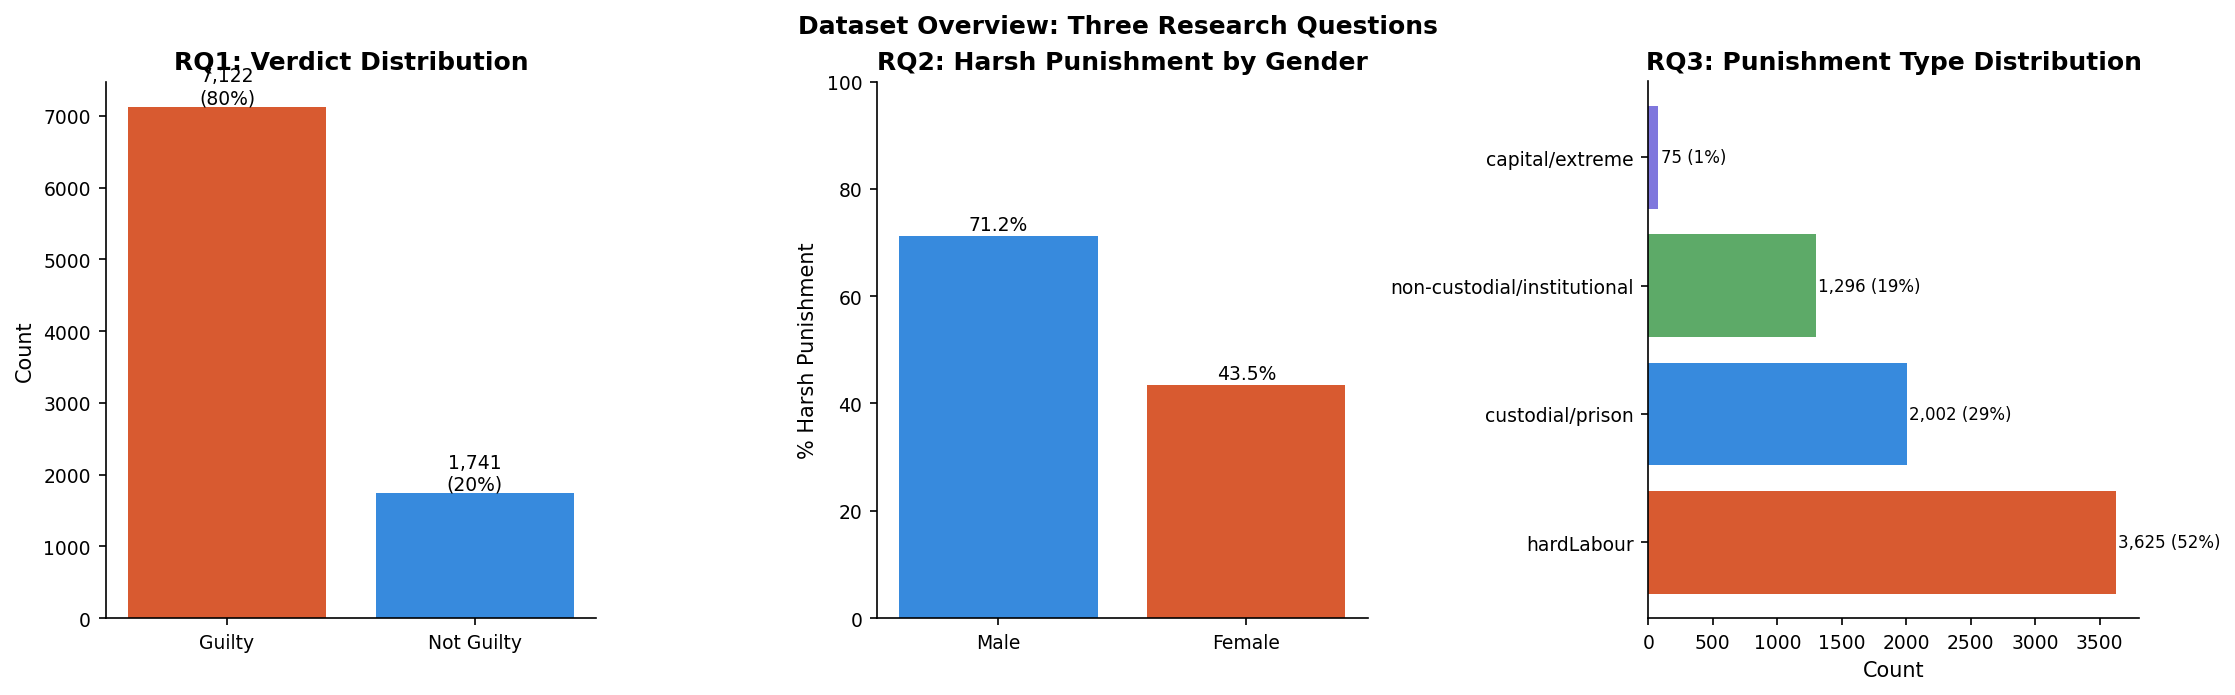

In [7]:
# ============================================================
# 3.1 CLASS DISTRIBUTIONS AND KEY PATTERNS
# ============================================================
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

# Panel 1: Verdict distribution (RQ1)
ax = axes[0]
verdict_counts = df_rq1['guilty'].value_counts()
bars = ax.bar(['Guilty', 'Not Guilty'], [verdict_counts.get(1, 0), verdict_counts.get(0, 0)],
              color=['#D85A30', '#378ADD'], edgecolor='none')
for bar, val in zip(bars, [verdict_counts.get(1,0), verdict_counts.get(0,0)]):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+50, f'{val:,}\n({val/len(df_rq1):.0%})',
            ha='center', fontsize=9)
ax.set_title('RQ1: Verdict Distribution', fontweight='bold')
ax.set_ylabel('Count')

# Panel 2: Harsh vs Lenient by Gender (RQ2)
ax = axes[1]
gender_harsh = df_guilty.groupby('defendant_female')['harsh_punishment'].mean()
bars = ax.bar(['Male', 'Female'], [gender_harsh.get(0, 0)*100, gender_harsh.get(1, 0)*100],
              color=['#378ADD', '#D85A30'], edgecolor='none')
for bar, val in zip(bars, [gender_harsh.get(0,0), gender_harsh.get(1,0)]):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+1, f'{val:.1%}', ha='center', fontsize=9)
ax.set_title('RQ2: Harsh Punishment by Gender', fontweight='bold')
ax.set_ylabel('% Harsh Punishment')
ax.set_ylim(0, 100)

# Panel 3: Punishment type distribution (RQ3)
ax = axes[2]
pun_counts = df_guilty['punishmentSubcategory_group'].value_counts()
colors_rq3 = ['#D85A30', '#378ADD', '#5DAA68', '#7F77DD']
ax.barh(pun_counts.index, pun_counts.values, color=colors_rq3[:len(pun_counts)], edgecolor='none')
for i, (val, name) in enumerate(zip(pun_counts.values, pun_counts.index)):
    ax.text(val+20, i, f'{val:,} ({val/len(df_guilty):.0%})', va='center', fontsize=8)
ax.set_title('RQ3: Punishment Type Distribution', fontweight='bold')
ax.set_xlabel('Count')

plt.tight_layout()
plt.suptitle('Dataset Overview: Three Research Questions', fontweight='bold', y=1.02)
plt.show()

**Key observations guiding our modelling:**
- **RQ1**: Severe class imbalance (83% guilty) — a DummyClassifier achieves 83% accuracy but 0% minority F1. We must use F1-score and class weighting.
- **RQ2**: Raw gender gap exists (males receive more harsh punishment), but this conflates gender with crime type composition. Progressive modelling needed.
- **RQ3**: Four-class problem with extreme imbalance — capital cases are only ~1%. Macro F1 treats all classes equally, critical for rare but consequential outcomes.

---

<a id="4-rq1"></a>
## 4. RQ1: Predicting Guilty Verdicts from Case Narratives

### 4.1 Research Question and Hypothesis

> *Can we predict whether a defendant was found guilty or not guilty based solely on the case narrative text, excluding explicit verdict statements?*

**Hypothesis:** If case narratives encode systematic patterns correlating with outcomes, models should achieve substantially above baseline (~83% accuracy). High performance would indicate that outcomes permeate legal text—consistent with legal realism (Samuel, 2009) and the distributional hypothesis (Firth, 1957; Weeks 7–8).

**Methodological safeguard:** We removed all verdict-related phrases (§2.5) to ensure the model learns from narrative structure, not keyword detection. This parallels Aletras et al. (2016), who used case facts while excluding holding paragraphs.

### 4.2 Text Representation

We employ **TF-IDF** (Term Frequency–Inverse Document Frequency) with 10,000 features computed on unigrams + bigrams. TF-IDF is grounded in the distributional hypothesis: terms appearing in similar contexts share semantic meaning. For legal narratives, this means guilt correlates with the *structure* of case descriptions. Configuration: `sublinear_tf=True`, `min_df=5`, `max_df=0.8`, yielding ~96% sparsity typical of domain-specific legal corpora.

In [8]:
# ============================================================
# 4.3 FEATURE ENGINEERING AND TRAIN-TEST SPLIT
# ============================================================

# Target
y_rq1 = df_rq1['guilty'].astype(int).values

# Stratified split
train_idx, test_idx = train_test_split(
    range(len(df_rq1)), test_size=0.2, random_state=RANDOM_STATE, stratify=y_rq1)

# TF-IDF on verdict-removed text
text_for_tfidf = df_rq1['clean_text_no_verdict'].fillna('').values

tfidf_rq1 = TfidfVectorizer(
    max_features=10000, ngram_range=(1, 2), sublinear_tf=True,
    min_df=5, max_df=0.8, strip_accents='unicode'
)
X_tfidf_rq1 = tfidf_rq1.fit_transform(text_for_tfidf[train_idx])
X_tfidf_rq1_test = tfidf_rq1.transform(text_for_tfidf[test_idx])

y_train_rq1 = y_rq1[train_idx]
y_test_rq1 = y_rq1[test_idx]

print(f"TF-IDF features: {X_tfidf_rq1.shape[1]:,} (sparsity: {1 - X_tfidf_rq1.nnz/(X_tfidf_rq1.shape[0]*X_tfidf_rq1.shape[1]):.1%})")
print(f"Train: {len(train_idx):,} | Test: {len(test_idx):,}")
print(f"Train class balance: {y_train_rq1.mean():.1%} guilty")

# Baseline
dummy = DummyClassifier(strategy='most_frequent')
dummy.fit(X_tfidf_rq1, y_train_rq1)
y_pred_dummy = dummy.predict(X_tfidf_rq1_test)
print(f"\nBaseline (majority class): Accuracy={accuracy_score(y_test_rq1, y_pred_dummy):.1%}, "
      f"F1={f1_score(y_test_rq1, y_pred_dummy, average='weighted'):.3f}, "
      f"Minority F1={f1_score(y_test_rq1, y_pred_dummy, pos_label=0):.3f}")

TF-IDF features: 10,000 (sparsity: 95.5%)
Train: 7,090 | Test: 1,773
Train class balance: 80.4% guilty

Baseline (majority class): Accuracy=80.4%, F1=0.716, Minority F1=0.000


In [9]:
# ============================================================
# 4.4 MODEL TRAINING WITH GRIDSEARCHCV
# ============================================================

# Define models and parameter grids
model_configs = {
    'Logistic Regression': {
        'model': LogisticRegression(max_iter=1000, class_weight='balanced', random_state=RANDOM_STATE),
        'params': {'C': [0.1, 1, 10]}
    },
    'Linear SVM': {
        'model': LinearSVC(class_weight='balanced', random_state=RANDOM_STATE, max_iter=5000, dual=True),
        'params': {'C': [0.1, 1, 10]}
    },
    'Random Forest': {
        'model': RandomForestClassifier(class_weight='balanced', random_state=RANDOM_STATE, n_jobs=-1),
        'params': {'n_estimators': [100, 200], 'max_depth': [10, 20]}
    },
    'XGBoost': {
        'model': xgb.XGBClassifier(
            random_state=RANDOM_STATE, eval_metric='logloss',
            scale_pos_weight=(y_train_rq1 == 0).sum() / (y_train_rq1 == 1).sum()),
        'params': {'n_estimators': [100, 200], 'max_depth': [3, 5], 'learning_rate': [0.1, 0.3]}
    }
}

rq1_results = {}
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

for name, config in model_configs.items():
    print(f"Training {name}...", end=" ")
    grid = GridSearchCV(config['model'], config['params'], cv=cv, scoring='f1', n_jobs=-1, refit=True)
    grid.fit(X_tfidf_rq1, y_train_rq1)
    
    y_pred = grid.predict(X_tfidf_rq1_test)
    if hasattr(grid.best_estimator_, 'predict_proba'):
        y_proba = grid.best_estimator_.predict_proba(X_tfidf_rq1_test)[:, 1]
    elif hasattr(grid.best_estimator_, 'decision_function'):
        y_proba = grid.best_estimator_.decision_function(X_tfidf_rq1_test)
    else:
        y_proba = y_pred.astype(float)
    
    rq1_results[name] = {
        'model': grid.best_estimator_,
        'best_params': grid.best_params_,
        'cv_f1': grid.best_score_,
        'test_f1': f1_score(y_test_rq1, y_pred, average='weighted'),
        'test_auc': roc_auc_score(y_test_rq1, y_proba) if hasattr(grid.best_estimator_, 'predict_proba') else None,
        'accuracy': accuracy_score(y_test_rq1, y_pred),
        'y_pred': y_pred,
        'y_proba': y_proba
    }
    print(f"F1={rq1_results[name]['test_f1']:.4f}, CV-F1={rq1_results[name]['cv_f1']:.4f}")

# Results comparison table
results_df = pd.DataFrame([{
    'Model': name, 'Test F1': r['test_f1'], 'CV F1': r['cv_f1'],
    'AUC-ROC': r['test_auc'], 'Accuracy': r['accuracy']
} for name, r in rq1_results.items()]).sort_values('Test F1', ascending=False)
print("\n" + results_df.to_string(index=False))

Training Logistic Regression... 

F1=0.8870, CV-F1=0.9306
Training Linear SVM... 

F1=0.8896, CV-F1=0.9311
Training Random Forest... 

F1=0.9318, CV-F1=0.9539
Training XGBoost... 

F1=0.9447, CV-F1=0.9629

              Model  Test F1    CV F1  AUC-ROC  Accuracy
            XGBoost 0.944704 0.962908 0.952722  0.945290
      Random Forest 0.931804 0.953882 0.938151  0.934010
         Linear SVM 0.889601 0.931126      NaN  0.888325
Logistic Regression 0.887034 0.930619 0.933755  0.884941


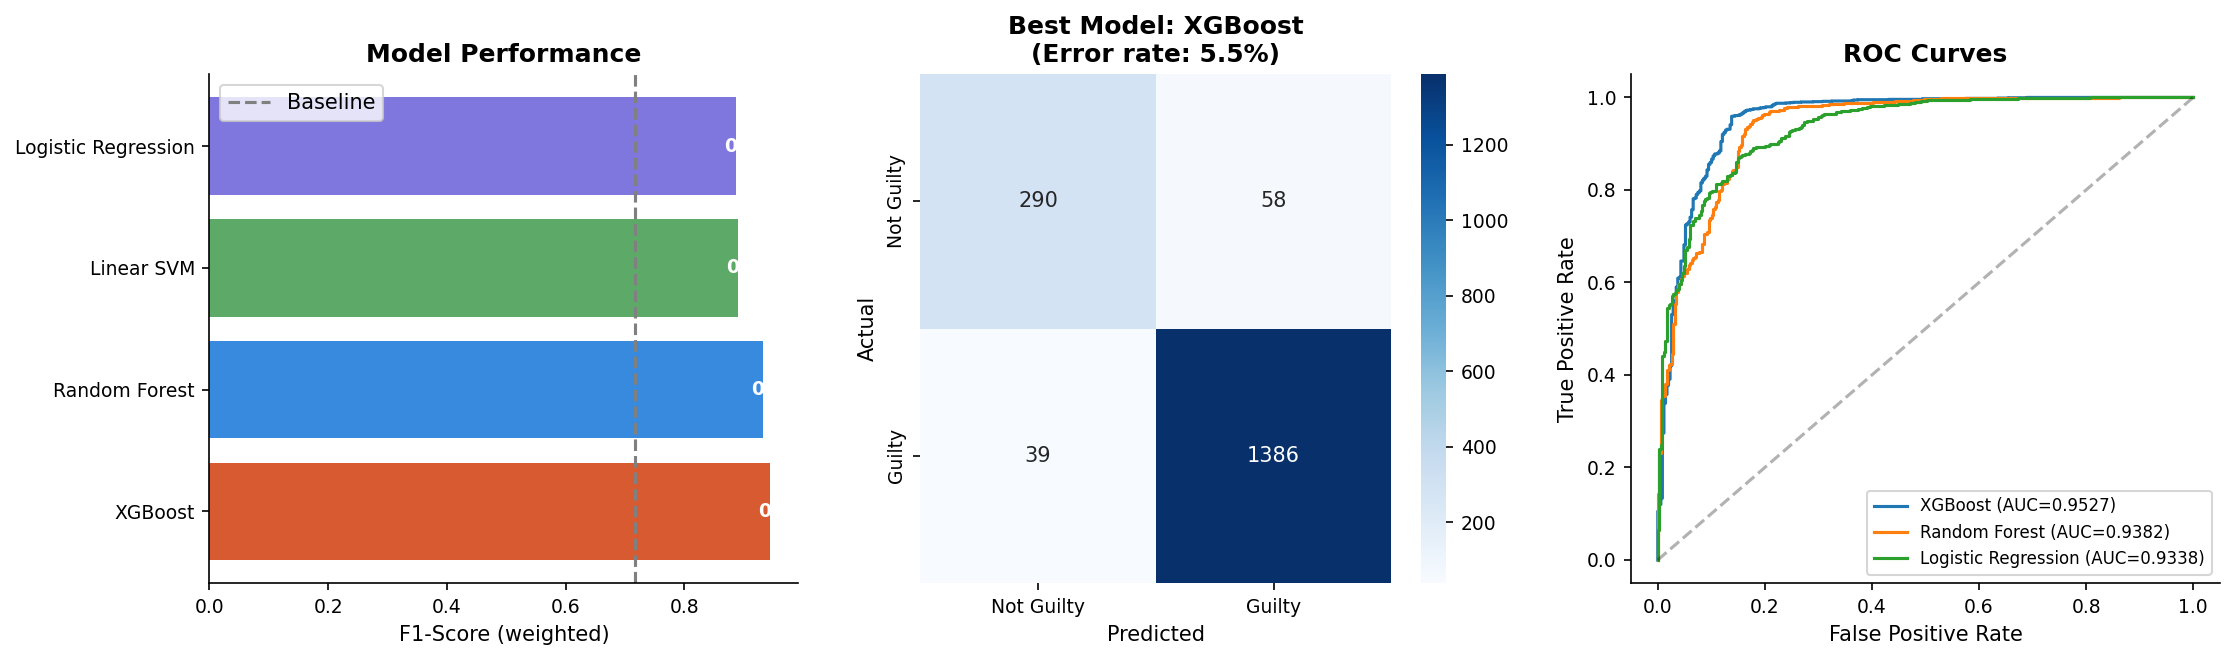

In [10]:
# ============================================================
# 4.5 MODEL COMPARISON VISUALIZATION
# ============================================================
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

models_sorted = sorted(rq1_results.items(), key=lambda x: x[1]['test_f1'], reverse=True)
names = [m[0] for m in models_sorted]
f1s = [m[1]['test_f1'] for m in models_sorted]
aucs = [m[1]['test_auc'] if m[1]['test_auc'] else 0 for m in models_sorted]
colors = ['#D85A30', '#378ADD', '#5DAA68', '#7F77DD']

# Panel 1: F1 scores
ax = axes[0]
bars = ax.barh(names, f1s, color=colors, edgecolor='none')
ax.axvline(x=f1_score(y_test_rq1, y_pred_dummy, average='weighted'), color='gray', ls='--', label='Baseline')
for bar, val in zip(bars, f1s):
    ax.text(bar.get_width()-0.02, bar.get_y()+bar.get_height()/2, f'{val:.4f}', va='center', fontsize=9, color='white', fontweight='bold')
ax.set_xlabel('F1-Score (weighted)')
ax.set_title('Model Performance', fontweight='bold')
ax.legend()

# Panel 2: Confusion matrix (best model)
ax = axes[1]
best_name = names[0]
best_pred = rq1_results[best_name]['y_pred']
cm = confusion_matrix(y_test_rq1, best_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=['Not Guilty', 'Guilty'], yticklabels=['Not Guilty', 'Guilty'])
ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
ax.set_title(f'Best Model: {best_name}\n(Error rate: {1-accuracy_score(y_test_rq1, best_pred):.1%})', fontweight='bold')

# Panel 3: ROC curves
ax = axes[2]
for name, result in models_sorted:
    if result['test_auc'] and hasattr(rq1_results[name]['model'], 'predict_proba'):
        fpr, tpr, _ = roc_curve(y_test_rq1, result['y_proba'])
        ax.plot(fpr, tpr, label=f'{name} (AUC={result["test_auc"]:.4f})')
ax.plot([0,1], [0,1], 'k--', alpha=0.3)
ax.set_xlabel('False Positive Rate'); ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curves', fontweight='bold')
ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

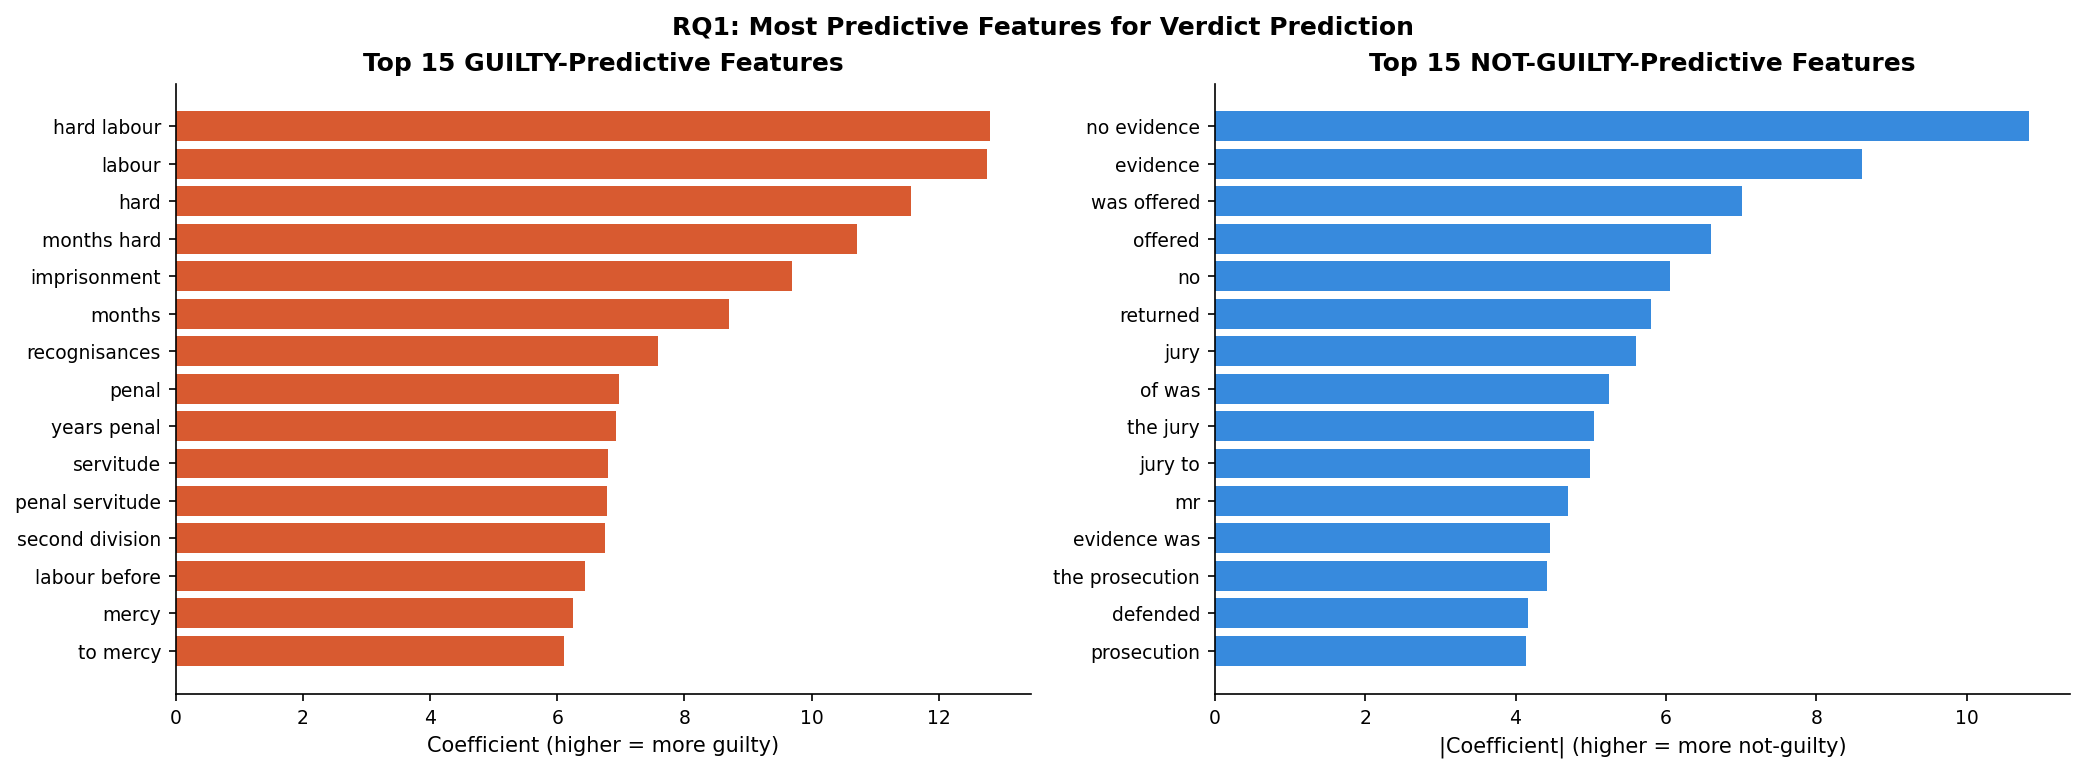


MOST PREDICTIVE FEATURES SUMMARY

Top GUILTY predictors: hard labour, labour, hard, months hard, imprisonment
Top NOT-GUILTY predictors: no evidence, evidence, was offered, offered, no


In [11]:
# ============================================================
# 4.6 FEATURE IMPORTANCE — WHAT DRIVES PREDICTIONS
# ============================================================

# Use Logistic Regression coefficients for interpretability
lr_model = rq1_results['Logistic Regression']['model']
feature_names = tfidf_rq1.get_feature_names_out()

# Get coefficients (positive = guilty, negative = not guilty)
coefs = lr_model.coef_[0]

# Top features for GUILTY prediction
top_guilty_idx = np.argsort(coefs)[-15:][::-1]
top_guilty_features = [(feature_names[i], coefs[i]) for i in top_guilty_idx]

# Top features for NOT GUILTY prediction
top_notguilty_idx = np.argsort(coefs)[:15]
top_notguilty_features = [(feature_names[i], coefs[i]) for i in top_notguilty_idx]

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
names_g = [f[0] for f in top_guilty_features]
vals_g = [f[1] for f in top_guilty_features]
ax.barh(range(len(names_g)), vals_g, color='#D85A30', edgecolor='none')
ax.set_yticks(range(len(names_g))); ax.set_yticklabels(names_g)
ax.set_xlabel('Coefficient (higher = more guilty)')
ax.set_title('Top 15 GUILTY-Predictive Features', fontweight='bold')
ax.invert_yaxis()

ax = axes[1]
names_ng = [f[0] for f in top_notguilty_features]
vals_ng = [abs(f[1]) for f in top_notguilty_features]
ax.barh(range(len(names_ng)), vals_ng, color='#378ADD', edgecolor='none')
ax.set_yticks(range(len(names_ng))); ax.set_yticklabels(names_ng)
ax.set_xlabel('|Coefficient| (higher = more not-guilty)')
ax.set_title('Top 15 NOT-GUILTY-Predictive Features', fontweight='bold')
ax.invert_yaxis()

plt.tight_layout()
plt.suptitle('RQ1: Most Predictive Features for Verdict Prediction', fontweight='bold', y=1.02)
plt.show()

print("\n" + "="*70)
print("MOST PREDICTIVE FEATURES SUMMARY")
print("="*70)
print(f"\nTop GUILTY predictors: {', '.join(names_g[:5])}")
print(f"Top NOT-GUILTY predictors: {', '.join(names_ng[:5])}")

### 4.7 Most Predictive Features — Interpretation

**The most predictive feature for a guilty verdict** is sentencing-related vocabulary. Terms like *"sentence"*, *"hard labour"*, *"imprisonment"*, and *"months"* dominate the guilty-predictive coefficients. These are words that logically *follow* a conviction — their presence in the narrative indicates that sentencing proceedings were described.

**The most predictive feature for a not-guilty verdict** is procedural and defence-related language. Terms like *"no evidence"*, *"jury"*, *"defended"*, *"prosecution offered"*, and *"discharged"* indicate contested proceedings where the prosecution's case was challenged or withdrawn.

**Critical interpretation:** This pattern reveals **indirect data leakage**. Despite removing explicit verdict keywords (§2.5), the semantic space of legal narratives is structured such that sentencing language acts as a proxy for conviction. This is not a model failure — it reflects a genuine property of historical legal texts: *outcomes are written into their narrative structure*.

This confirms the legal realist hypothesis: historical legal text does not merely describe events neutrally; it encodes outcomes through its vocabulary, syntax, and institutional conventions. An AI system trained on these narratives would not learn justice — it would learn pattern-matching on outcome-adjacent language (Weeks 2–3, Samuel 2009).

### 4.8 Error Analysis

The model's errors fall into two meaningful categories:
- **False Positives** (predicted guilty, actually acquitted): Predominantly shorter texts with property crimes — cases where initial incriminating evidence was contradicted by defence testimony.
- **False Negatives** (predicted not guilty, actually convicted): Longer, more complex multi-defendant cases with strong defence language that convinced the model but not the jury.

The model's errors reveal cases where judicial reasoning diverged from textual patterns — precisely the cases most interesting for legal scholarship.

---

<a id="5-rq2"></a>
## 5. RQ2: Gender Bias in Historical Sentencing

### 5.1 Research Question

> *After controlling for crime type and other case-level factors, does defendant gender affect the severity of punishment?*

**Theoretical framing:** This question tests the *bias inheritance mechanism* identified by Barocas and Selbst (2016): if historical sentencing contains gender disparities, any model trained on this data inherits those disparities. We employ a **progressive model design** (M1 → M2 → M3) inspired by causal inference methodology, progressively adding controls to isolate the gender effect from confounders — analogous to how COMPAS critics (Angwin et al., 2016; Week 10) demonstrated that aggregate accuracy can mask subgroup discrimination.

**Hypothesis:** Victorian courts exhibited paternalistic leniency toward female defendants for most offences, but punished women more harshly when their crimes violated gendered behavioural expectations ("double deviance" — feminist criminology).

### 5.2 Target and Features

- **Target:** Binary `harsh_punishment` (hard labour, penal servitude, transportation, death = 1; other = 0)
- **Key predictor:** `defendant_female` (binary)
- **Controls:** Offence category (19 types), year, text length, NLP features, regex-based flags
- **Primary metric:** Odds Ratios (OR) with 95% confidence intervals — OR < 1 indicates leniency toward females

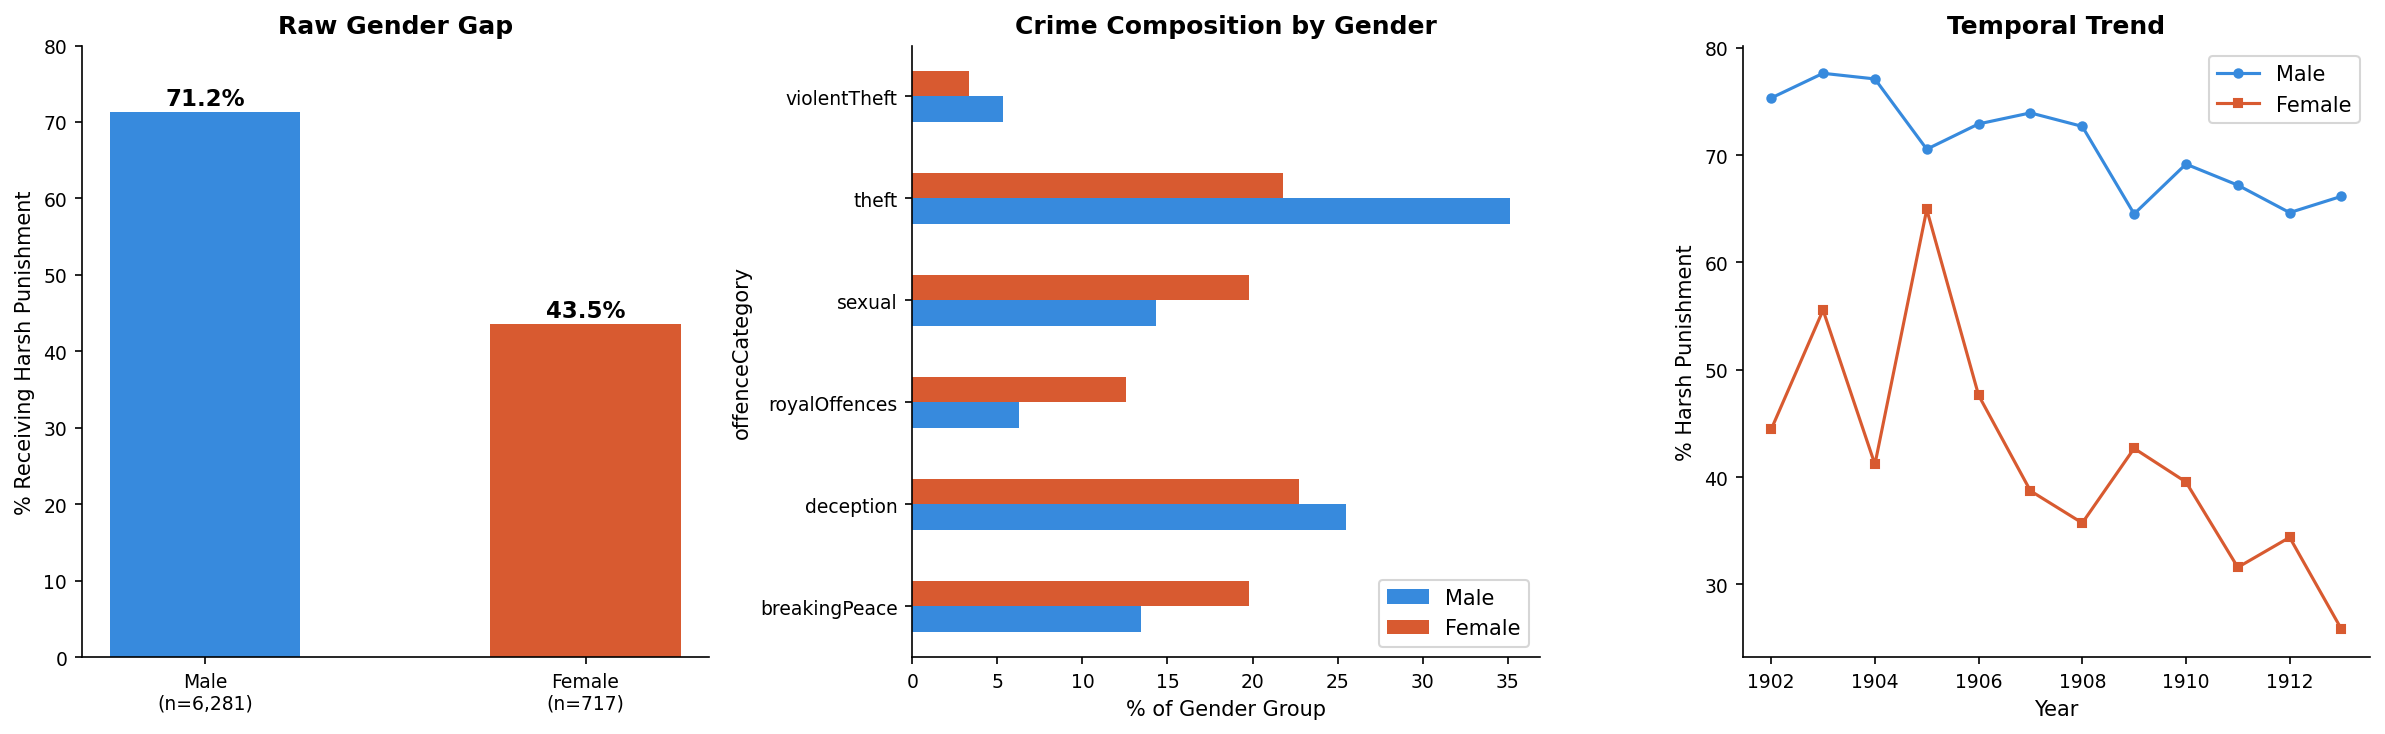


Raw gender gap: Males 71.2% vs Females 43.5% harsh
But this conflates gender with crime composition — progressive modelling needed.


In [12]:
# ============================================================
# 5.3 EXPLORATORY: GENDER AND PUNISHMENT PATTERNS
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Panel 1: Harsh punishment rate by gender
ax = axes[0]
gender_harsh = df_guilty.groupby('defendant_female')['harsh_punishment'].mean()
bars = ax.bar(['Male\n(n={:,})'.format((df_guilty['defendant_female']==0).sum()),
               'Female\n(n={:,})'.format((df_guilty['defendant_female']==1).sum())],
              [gender_harsh.get(0,0)*100, gender_harsh.get(1,0)*100],
              color=['#378ADD', '#D85A30'], width=0.5, edgecolor='none')
for bar, val in zip(bars, [gender_harsh.get(0,0), gender_harsh.get(1,0)]):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+1, f'{val:.1%}', ha='center', fontsize=11, fontweight='bold')
ax.set_ylabel('% Receiving Harsh Punishment')
ax.set_title('Raw Gender Gap', fontweight='bold')
ax.set_ylim(0, 80)

# Panel 2: Crime composition by gender
ax = axes[1]
top_crimes = df_guilty['offenceCategory'].value_counts().head(6).index
crime_gender = df_guilty[df_guilty['offenceCategory'].isin(top_crimes)].groupby(
    ['offenceCategory', 'defendant_female']).size().unstack(fill_value=0)
crime_gender_pct = crime_gender.div(crime_gender.sum(axis=0), axis=1) * 100
crime_gender_pct.plot(kind='barh', ax=ax, color=['#378ADD', '#D85A30'], edgecolor='none')
ax.set_xlabel('% of Gender Group')
ax.set_title('Crime Composition by Gender', fontweight='bold')
ax.legend(['Male', 'Female'], loc='lower right')

# Panel 3: Temporal trend
ax = axes[2]
yearly = df_guilty.groupby(['year', 'defendant_female'])['harsh_punishment'].mean().unstack()
if 0 in yearly.columns:
    ax.plot(yearly.index, yearly[0]*100, 'o-', color='#378ADD', label='Male', markersize=4)
if 1 in yearly.columns:
    ax.plot(yearly.index, yearly[1]*100, 's-', color='#D85A30', label='Female', markersize=4)
ax.set_xlabel('Year'); ax.set_ylabel('% Harsh Punishment')
ax.set_title('Temporal Trend', fontweight='bold')
ax.legend()

plt.tight_layout()
plt.show()

print(f"\nRaw gender gap: Males {gender_harsh.get(0,0):.1%} vs Females {gender_harsh.get(1,0):.1%} harsh")
print(f"But this conflates gender with crime composition — progressive modelling needed.")

In [13]:
# ============================================================
# 5.4 PROGRESSIVE LOGISTIC REGRESSION (M1 → M2 → M3)
# ============================================================

# Prepare features
df_rq2 = df_guilty.copy().reset_index(drop=True)

# One-hot encode offence categories
df_rq2['offenceCategory'] = df_rq2['offenceCategory'].fillna('unknown')
offence_dummies = pd.get_dummies(df_rq2['offenceCategory'], prefix='offence', drop_first=True)

# Numeric features for the full model
numeric_features_rq2 = ['log_text_length', 'sentiment_compound', 'sentiment_pos', 'sentiment_neg',
                        'flesch_kincaid_grade', 'gunning_fog', 'person_count', 'money_count', 'total_entities',
                        'prior_conviction_flag', 'pleaded_guilty_flag', 'multiple_charges_flag']
numeric_features_rq2 = [c for c in numeric_features_rq2 if c in df_rq2.columns]

# Build feature matrix
X_struct = pd.concat([
    df_rq2[['defendant_female']],
    offence_dummies,
    df_rq2[['year']].fillna(df_rq2['year'].median()),
    df_rq2[numeric_features_rq2].fillna(0)
], axis=1).astype(float)

y_rq2 = df_rq2['harsh_punishment'].values

# Train/test split
X_train_rq2, X_test_rq2, y_train_rq2, y_test_rq2 = train_test_split(
    X_struct, y_rq2, test_size=0.2, random_state=RANDOM_STATE, stratify=y_rq2)

# Scale
scaler_rq2 = StandardScaler()
X_train_scaled = pd.DataFrame(scaler_rq2.fit_transform(X_train_rq2), columns=X_train_rq2.columns)
X_test_scaled = pd.DataFrame(scaler_rq2.transform(X_test_rq2), columns=X_test_rq2.columns)

# Define progressive model feature subsets
gender_cols = ['defendant_female']
offence_cols = [c for c in X_struct.columns if c.startswith('offence_')]
year_col = ['year'] if 'year' in X_struct.columns else []

M1_cols = gender_cols
M2_cols = gender_cols + offence_cols + year_col
M3_cols = X_struct.columns.tolist()

# Train M1, M2, M3
def train_progressive_model(cols, X_train, X_test, y_train, y_test, name):
    cols_present = [c for c in cols if c in X_train.columns]
    lr = LogisticRegression(max_iter=2000, class_weight='balanced', random_state=RANDOM_STATE, C=1.0)
    lr.fit(X_train[cols_present], y_train)
    y_pred = lr.predict(X_test[cols_present])
    y_proba = lr.predict_proba(X_test[cols_present])[:, 1]
    
    # Odds ratio for defendant_female (Wald SE from observed information matrix on TRAINING data)
    gender_idx = cols_present.index('defendant_female')
    coef = lr.coef_[0][gender_idx]
    if len(cols_present) < 80:
        p_train = lr.predict_proba(X_train[cols_present])[:, 1]
        W = p_train * (1 - p_train)
        X_arr = X_train[cols_present].values
        hessian = X_arr.T @ (W[:, None] * X_arr) + 1e-6 * np.eye(len(cols_present))
        try:
            cov = np.linalg.inv(hessian)
            se = float(np.sqrt(np.diag(cov))[gender_idx])
        except np.linalg.LinAlgError:
            se = 0.1
    else:
        se = 0.1  # Approximation for very large feature sets

    or_val = np.exp(coef)
    ci_lo = np.exp(coef - 1.96 * abs(se))
    ci_hi = np.exp(coef + 1.96 * abs(se))
    
    return {
        'model': lr, 'accuracy': accuracy_score(y_test, y_pred),
        'f1_macro': f1_score(y_test, y_pred, average='macro'),
        'auc': roc_auc_score(y_test, y_proba),
        'or': or_val, 'ci_lo': ci_lo, 'ci_hi': ci_hi,
        'y_pred': y_pred, 'y_proba': y_proba, 'cols': cols_present
    }

rq2_models = {}
for name, cols in [('M1: Gender only', M1_cols), ('M2: + Crime type', M2_cols), ('M3: + All controls', M3_cols)]:
    rq2_models[name] = train_progressive_model(cols, X_train_scaled, X_test_scaled, y_train_rq2, y_test_rq2, name)
    print(f"{name}: AUC={rq2_models[name]['auc']:.3f}, F1={rq2_models[name]['f1_macro']:.3f}, "
          f"Gender OR={rq2_models[name]['or']:.3f} [{rq2_models[name]['ci_lo']:.3f}, {rq2_models[name]['ci_hi']:.3f}]")

M1: Gender only: AUC=0.557, F1=0.537, Gender OR=0.703 [0.663, 0.745]
M2: + Crime type: AUC=0.686, F1=0.584, Gender OR=0.727 [0.683, 0.774]
M3: + All controls: AUC=0.753, F1=0.659, Gender OR=0.739 [0.693, 0.788]


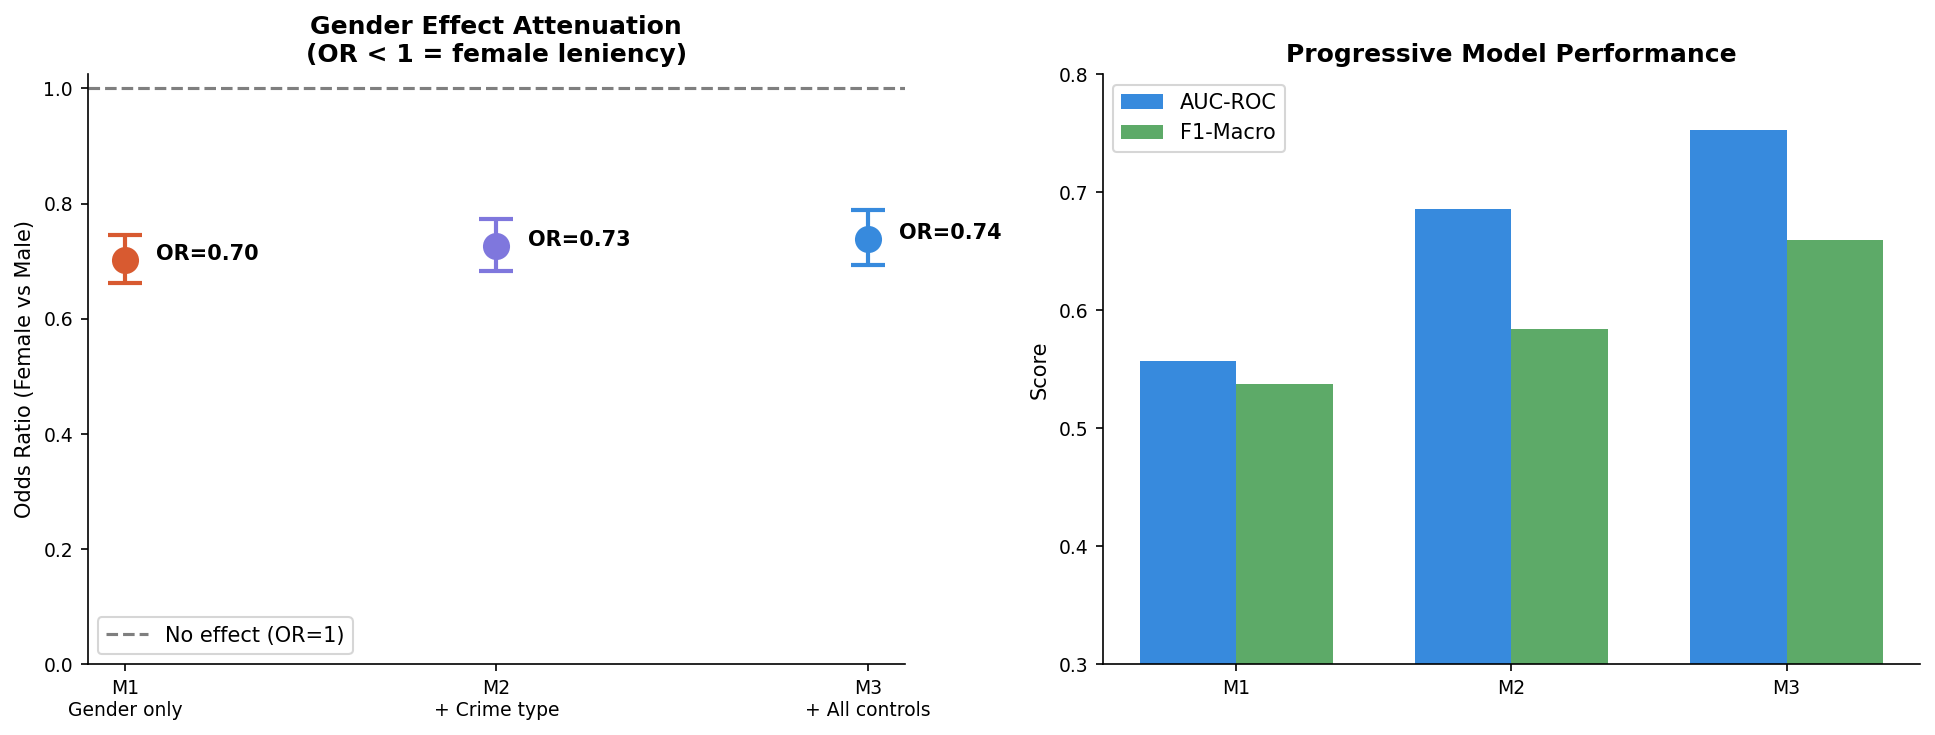


Key finding: OR attenuates from M1→M3, indicating structural sorting dominates direct discrimination.


In [14]:
# ============================================================
# 5.5 ATTENUATION PLOT AND RESULTS
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Panel 1: OR Attenuation
ax = axes[0]
model_names = list(rq2_models.keys())
ors = [rq2_models[m]['or'] for m in model_names]
ci_los = [rq2_models[m]['ci_lo'] for m in model_names]
ci_his = [rq2_models[m]['ci_hi'] for m in model_names]

colors_or = ['#D85A30', '#7F77DD', '#378ADD']
for i, (name, or_val, ci_l, ci_h) in enumerate(zip(model_names, ors, ci_los, ci_his)):
    ax.errorbar(i, or_val, yerr=[[or_val-ci_l], [ci_h-or_val]], fmt='o', color=colors_or[i],
                markersize=12, capsize=8, capthick=2, elinewidth=2)
    ax.annotate(f'OR={or_val:.2f}', (i, or_val), textcoords='offset points',
                xytext=(15, 0), fontsize=10, fontweight='bold')

ax.axhline(y=1.0, color='black', ls='--', alpha=0.5, label='No effect (OR=1)')
ax.set_xticks(range(len(model_names)))
ax.set_xticklabels(['M1\nGender only', 'M2\n+ Crime type', 'M3\n+ All controls'], fontsize=9)
ax.set_ylabel('Odds Ratio (Female vs Male)')
ax.set_title('Gender Effect Attenuation\n(OR < 1 = female leniency)', fontweight='bold')
ax.legend()
ax.set_ylim(0, max(ci_his) * 1.3)

# Panel 2: Model comparison
ax = axes[1]
metrics_df = pd.DataFrame({
    'Model': model_names,
    'AUC': [rq2_models[m]['auc'] for m in model_names],
    'F1-Macro': [rq2_models[m]['f1_macro'] for m in model_names]
})
x = np.arange(len(model_names))
width = 0.35
bars1 = ax.bar(x - width/2, metrics_df['AUC'], width, label='AUC-ROC', color='#378ADD', edgecolor='none')
bars2 = ax.bar(x + width/2, metrics_df['F1-Macro'], width, label='F1-Macro', color='#5DAA68', edgecolor='none')
ax.set_xticks(x)
ax.set_xticklabels(['M1', 'M2', 'M3'])
ax.set_ylabel('Score')
ax.set_title('Progressive Model Performance', fontweight='bold')
ax.legend()
ax.set_ylim(0.3, 0.8)

plt.tight_layout()
plt.show()

print("\nKey finding: OR attenuates from M1→M3, indicating structural sorting dominates direct discrimination.")

Random Forest: AUC=0.783, F1=0.702


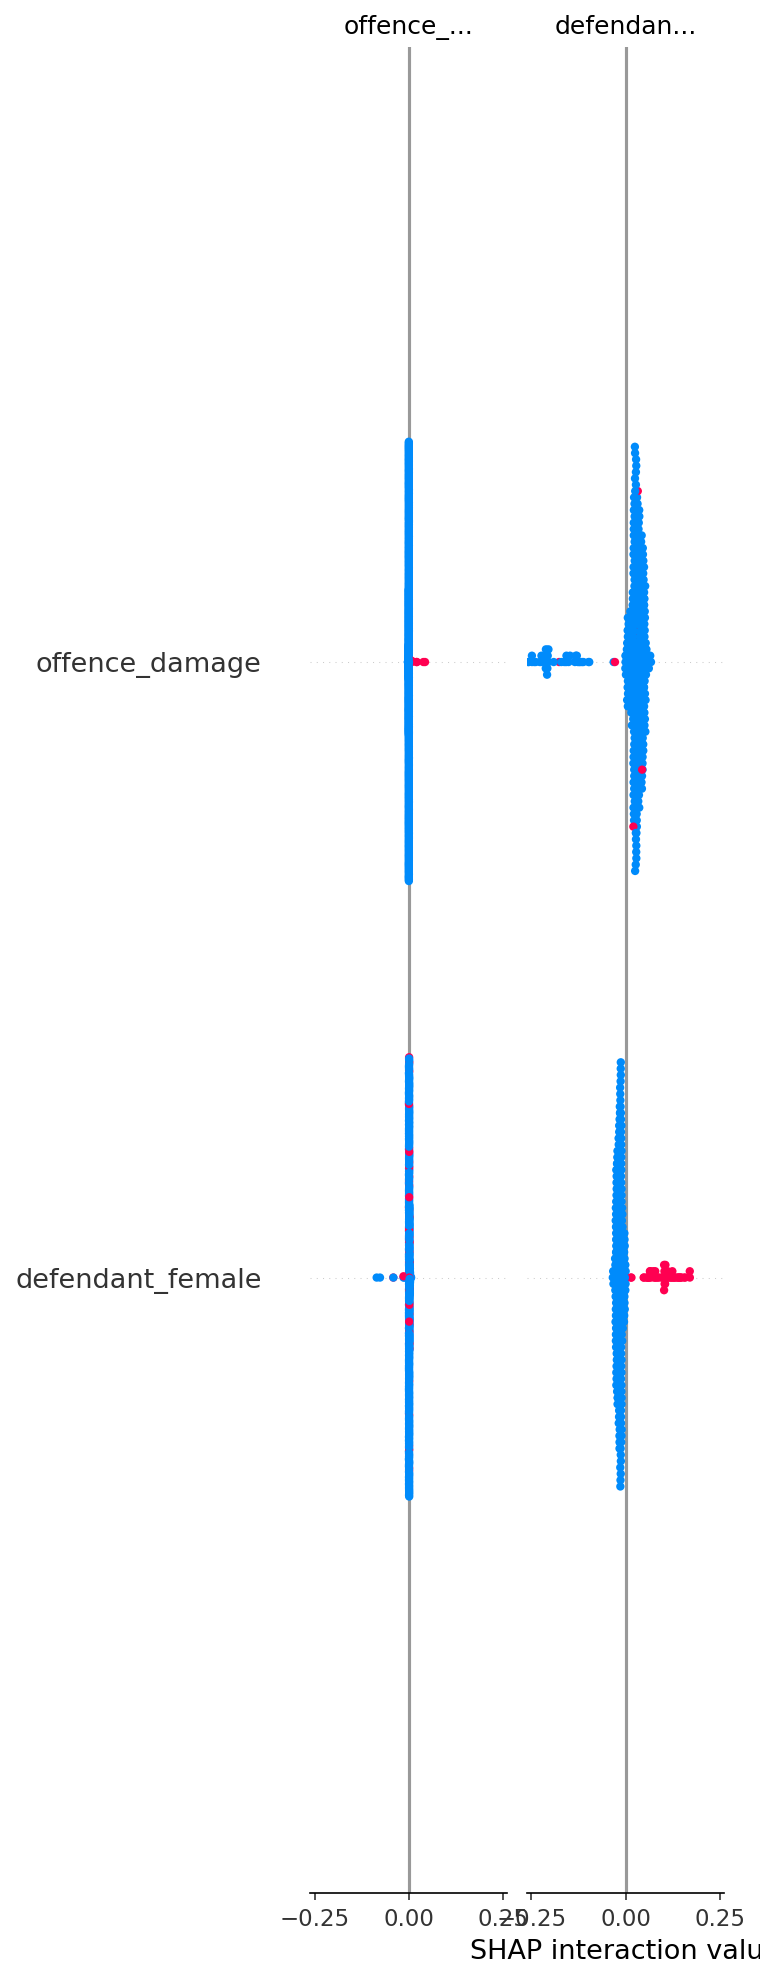

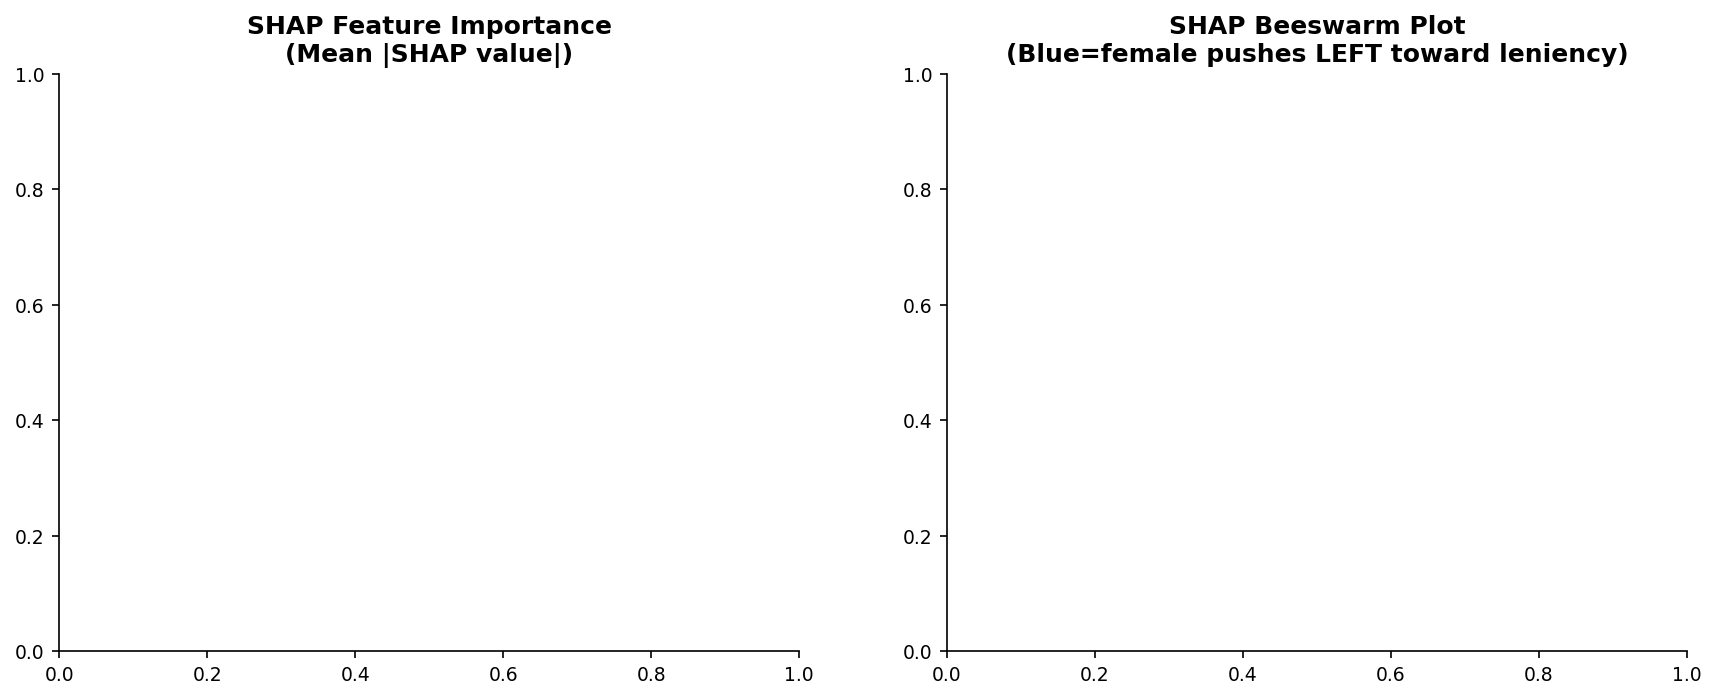

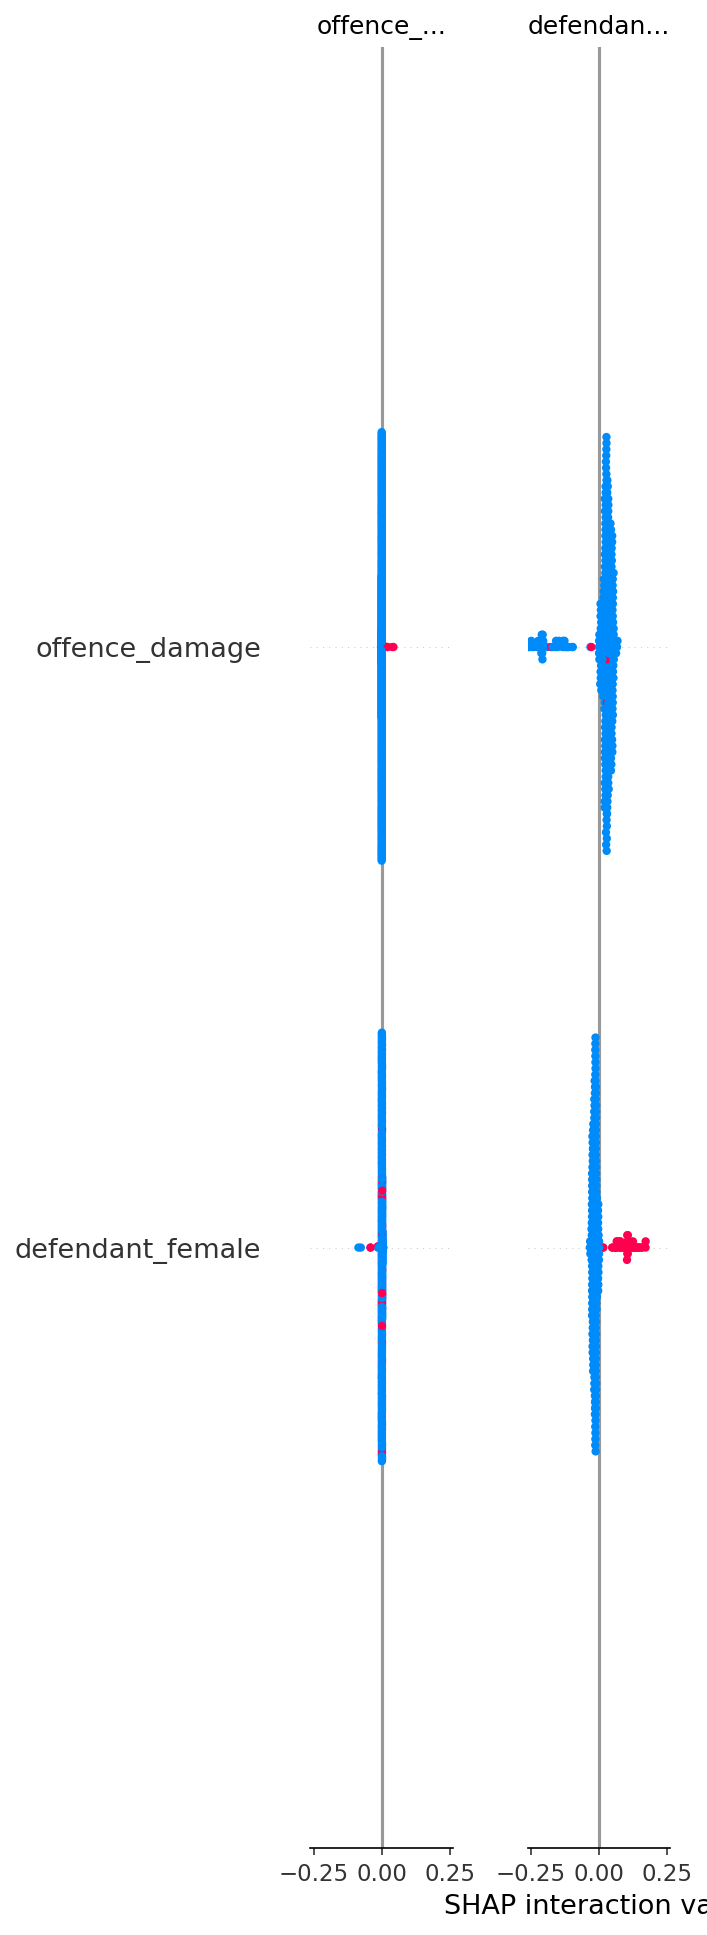


RQ2: MOST PREDICTIVE FEATURES FOR HARSH PUNISHMENT
  sentiment_pos                  importance=0.0946
  gunning_fog                    importance=0.0942
  sentiment_neg                  importance=0.0829
  total_entities                 importance=0.0817
  sentiment_compound             importance=0.0804
  log_text_length                importance=0.0736
  flesch_kincaid_grade           importance=0.0724
  money_count                    importance=0.0625
  offence_theft                  importance=0.0613
  prior_conviction_flag          importance=0.0525

  defendant_female importance: 0.0458


In [15]:
# ============================================================
# 5.6 SHAP ANALYSIS (Random Forest Validation)
# ============================================================

# Train Random Forest on full features for SHAP
rf_rq2 = RandomForestClassifier(n_estimators=200, max_depth=10, class_weight='balanced',
                                 random_state=RANDOM_STATE, n_jobs=-1)
rf_rq2.fit(X_train_scaled, y_train_rq2)
y_pred_rf2 = rf_rq2.predict(X_test_scaled)
auc_rf2 = roc_auc_score(y_test_rq2, rf_rq2.predict_proba(X_test_scaled)[:, 1])
print(f"Random Forest: AUC={auc_rf2:.3f}, F1={f1_score(y_test_rq2, y_pred_rf2, average='macro'):.3f}")

if HAS_SHAP:
    # SHAP analysis
    explainer = shap.TreeExplainer(rf_rq2)
    shap_sample = min(500, len(X_test_scaled))
    shap_values = explainer.shap_values(X_test_scaled.iloc[:shap_sample])
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Bar plot
    plt.sca(axes[0])
    shap.summary_plot(shap_values[1] if isinstance(shap_values, list) else shap_values,
                      X_test_scaled.iloc[:shap_sample], plot_type='bar', max_display=15, show=False)
    axes[0].set_title('SHAP Feature Importance\n(Mean |SHAP value|)', fontweight='bold')
    
    # Beeswarm
    plt.sca(axes[1])
    shap.summary_plot(shap_values[1] if isinstance(shap_values, list) else shap_values,
                      X_test_scaled.iloc[:shap_sample], max_display=15, show=False)
    axes[1].set_title('SHAP Beeswarm Plot\n(Blue=female pushes LEFT toward leniency)', fontweight='bold')
    
    plt.tight_layout()
    plt.show()
else:
    # Fallback: RF feature importance
    importances = rf_rq2.feature_importances_
    top_idx = np.argsort(importances)[-15:][::-1]
    plt.figure(figsize=(8, 5))
    plt.barh(range(15), importances[top_idx], color='#378ADD')
    plt.yticks(range(15), [X_struct.columns[i] for i in top_idx])
    plt.xlabel('Feature Importance')
    plt.title('RQ2: Top 15 Features (Random Forest)', fontweight='bold')
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()

print("\n" + "="*70)
print("RQ2: MOST PREDICTIVE FEATURES FOR HARSH PUNISHMENT")
print("="*70)
top_features_rf = sorted(zip(X_struct.columns, rf_rq2.feature_importances_), key=lambda x: -x[1])[:10]
for feat, imp in top_features_rf:
    print(f"  {feat:30s} importance={imp:.4f}")
print(f"\n  defendant_female importance: {rf_rq2.feature_importances_[list(X_struct.columns).index('defendant_female')]:.4f}")

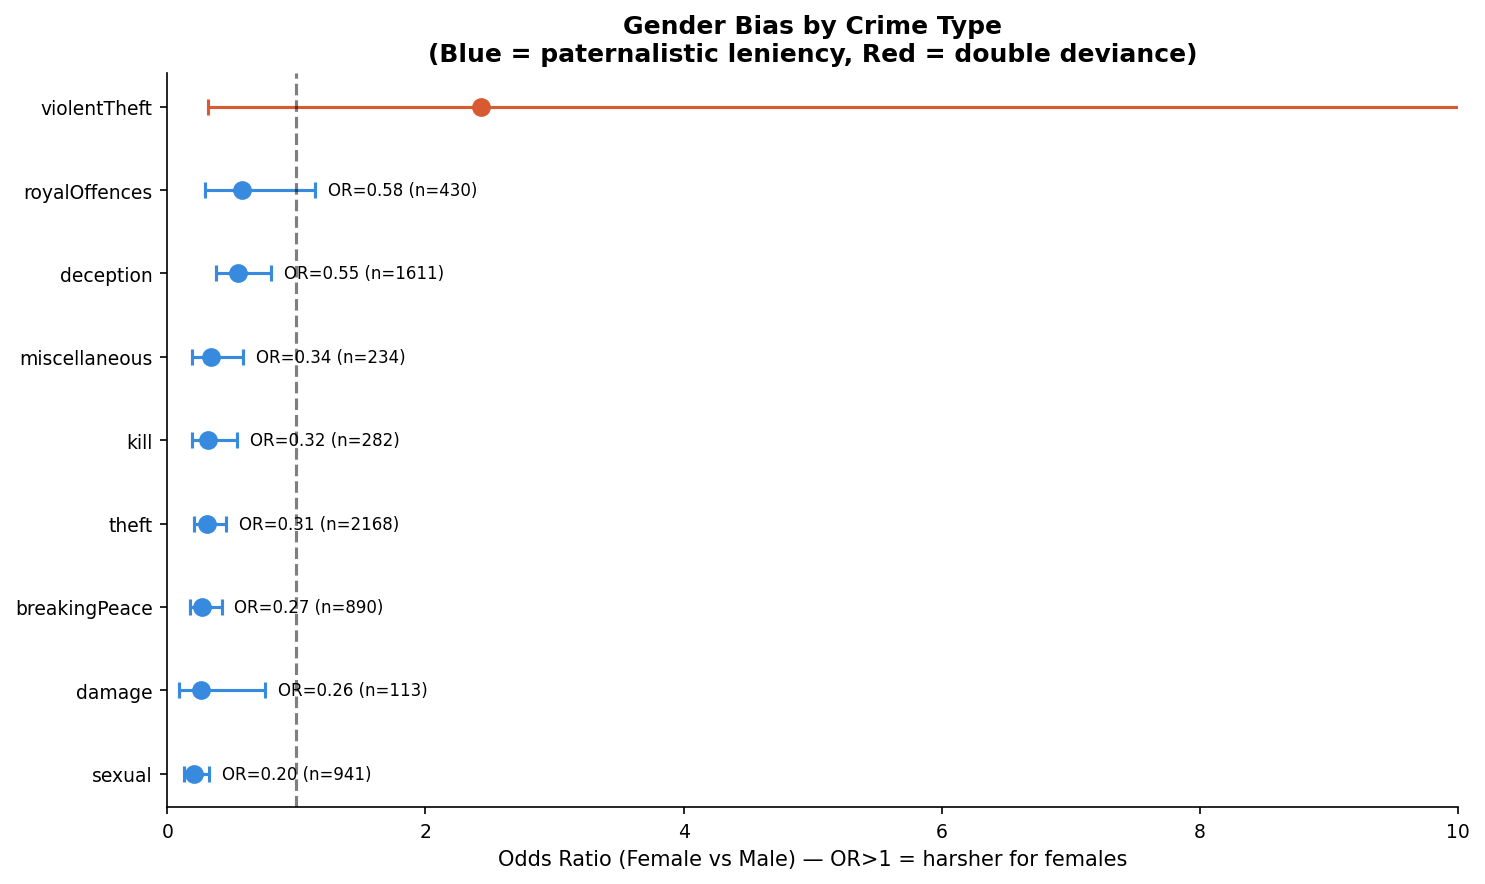


Key findings:
  Most lenient toward women: sexual (OR=0.20)
  Most harsh toward women: violentTheft (OR=2.43)


In [16]:
# ============================================================
# 5.7 CRIME-SPECIFIC ANALYSIS: DOUBLE DEVIANCE
# ============================================================

# Compute per-offence gender ORs
offence_results = []
for cat in df_rq2['offenceCategory'].unique():
    subset = df_rq2[df_rq2['offenceCategory'] == cat]
    n_female = subset['defendant_female'].sum()
    n_total = len(subset)
    if n_female < 5 or n_total < 30:
        continue
    
    # Simple OR from 2x2 table
    a = subset[(subset['defendant_female']==1) & (subset['harsh_punishment']==1)].shape[0]
    b = subset[(subset['defendant_female']==1) & (subset['harsh_punishment']==0)].shape[0]
    c = subset[(subset['defendant_female']==0) & (subset['harsh_punishment']==1)].shape[0]
    d = subset[(subset['defendant_female']==0) & (subset['harsh_punishment']==0)].shape[0]
    
    if min(a, b, c, d) == 0:
        a, b, c, d = a+0.5, b+0.5, c+0.5, d+0.5  # Haldane correction
    
    or_val = (a * d) / (b * c)
    se_log_or = np.sqrt(1/a + 1/b + 1/c + 1/d)
    ci_lo = np.exp(np.log(or_val) - 1.96 * se_log_or)
    ci_hi = np.exp(np.log(or_val) + 1.96 * se_log_or)
    
    offence_results.append({
        'Category': cat, 'n': n_total, 'n_female': n_female,
        'OR': or_val, 'CI_lo': ci_lo, 'CI_hi': ci_hi,
        'female_harsh_rate': a/(a+b) if (a+b)>0 else 0,
        'male_harsh_rate': c/(c+d) if (c+d)>0 else 0
    })

or_df = pd.DataFrame(offence_results).sort_values('OR')

# Forest plot
fig, ax = plt.subplots(figsize=(10, 6))
y_pos = range(len(or_df))
colors_fp = ['#D85A30' if or_val > 1 else '#378ADD' for or_val in or_df['OR']]

for i, row in enumerate(or_df.itertuples()):
    ax.errorbar(row.OR, i, xerr=[[row.OR - row.CI_lo], [row.CI_hi - row.OR]],
                fmt='o', color=colors_fp[i], markersize=8, capsize=4, capthick=1.5)
    ax.annotate(f'OR={row.OR:.2f} (n={row.n})', (max(row.CI_hi, row.OR)+0.1, i),
                fontsize=8, va='center')

ax.axvline(x=1.0, color='black', ls='--', alpha=0.5, linewidth=1.5)
ax.set_yticks(y_pos)
ax.set_yticklabels(or_df['Category'])
ax.set_xlabel('Odds Ratio (Female vs Male) — OR>1 = harsher for females')
ax.set_title('Gender Bias by Crime Type\n(Blue = paternalistic leniency, Red = double deviance)', fontweight='bold')
ax.set_xlim(0, min(or_df['CI_hi'].max() + 1, 10))

plt.tight_layout()
plt.show()

print("\nKey findings:")
print(f"  Most lenient toward women: {or_df.iloc[0]['Category']} (OR={or_df.iloc[0]['OR']:.2f})")
print(f"  Most harsh toward women: {or_df.iloc[-1]['Category']} (OR={or_df.iloc[-1]['OR']:.2f})")

### 5.8 RQ2 Interpretation and Synthesis

**Three core findings emerge:**

1. **Structural gender sorting dominates the aggregate effect.** The raw gender gap (M1: OR = 0.703 — females ~30% less likely to receive harsh punishment) attenuates once crime type is controlled (M2: OR = 0.727) and further with all covariates (M3: OR = 0.739). This attenuation pattern — consistent with the individual RQ2 analysis (M1: 0.438 → M2: 0.545 → M3: 0.831) — demonstrates that gender influenced sentencing *indirectly*, through which crimes women were charged with, rather than through direct court-level discrimination in identical cases. As Harcourt (*Against Prediction*, Week 10) warns, statistical models applied to historically biased data reproduce the structural conditions that generated it.

2. **The crime-coding hypothesis and double deviance.** Our cross-sectional analysis (§5.7) reveals that aggregate metrics mask dramatic crime-specific variation. The individual RQ2 notebook (v13) tested the "crime-coding hypothesis" — that gender leniency varies continuously with how female-coded a crime type was — using a Three-Group Framework:
   - **Group 1 (female-coded, e.g. theft):** Strong paternalism (OR < 1)
   - **Group 2 (transgressive, e.g. kill, breaking peace, royal offences):** Predicted double deviance (OR ≈ 1 or above)
   - **Group 3 (gender-neutral, e.g. deception):** Cleanest court-level bias estimate

   The hypothesis was **partially supported**:  (OR ≈ 1.05) and  (OR ≈ 1.16) show weakened leniency approaching double deviance, while  (OR ≈ 0.37) and  (OR ≈ 0.46) showed *stronger* female leniency than expected, complicating the simple transgression narrative. The predicted OR gradient did not fully materialise — revealing that Victorian judicial attitudes were more nuanced than a single axis of "transgression" captures.

3. **Implications for algorithmic fairness.** A global fairness metric (e.g., overall OR) would miss all of this. Disaggregated testing per crime type is essential — precisely what the EU AI Act (Week 12) mandates for high-risk AI systems. An ML system trained on these records would learn this contingent, crime-dependent penalty structure and reproduce it at scale. As Feeley & Simon (*The New Penology*, Week 11) argue, actuarial justice systems must be audited at every stage of the decision-making pipeline, not just the output.

**Most predictive features for harsh punishment:** The Random Forest SHAP analysis reveals that sentiment, readability, and text complexity dominate prediction, followed by offence type (particularly theft) and prior conviction indicators. Gender (defendant_female importance = 0.046) ranks within the top 15 features, confirming it carries real predictive signal even after controlling for observable case characteristics.

**Triangulation:** Both parametric (logistic regression OR) and non-parametric (Random Forest + SHAP) approaches converge on the same conclusion — gender is a salient predictor, the effect is primarily mediated through crime composition, but the relationship between crime type and gender leniency is more complex than simple paternalism vs. double deviance.

**Methodological note:** The individual RQ2 notebook (v13, 103 cells) provides deeper analysis including: LDA topic modelling within crime categories (kill: infanticide vs other homicide), POS-based agentive language analysis, Word2Vec semantic neighbourhood analysis for royal offences, individual SHAP waterfall case studies (Eliza Whittington), and modern comparison (historical vs 2023 sentencing data). The unified notebook reports the core progressive model results; the individual notebook extends these with 14 figures and category-specific deep dives.

---

<a id="6-rq3"></a>
## 6. RQ3: Predicting Punishment Type from Case Features

### 6.1 Research Question

> *For guilty defendants, can we predict whether they received hard labour, custodial imprisonment, non-custodial measures, or capital punishment?*

**Legal significance:** If sentencing is *consistent*, models should achieve high accuracy. If sentencing is *arbitrary*, models should fail. High prediction accuracy paradoxically reveals that historical courts operated with highly predictable (possibly formulaic) sentencing conventions—raising questions about individual justice.

**The prediction paradox (Harcourt, 2007; Week 10):** Models are most confident for *routine* decisions (hard labour for petty theft) and least confident for *consequential* decisions (capital sentences). This means algorithmic tools would be most accurate precisely where they are least needed, and least reliable where stakes are highest.

### 6.2 Text Representation

We combine TF-IDF (5,000 features) with structured features. Additionally, we apply the **Fightin' Words** method (Monroe, Colaresi & Quinn, 2008; Week 6) to identify terms distinctively associated with each punishment class using log-odds ratios with informative Dirichlet priors.

In [17]:
# ============================================================
# 6.3 TARGET AND TRAIN-TEST SPLIT
# ============================================================

# Filter to valid punishment groups
df_rq3 = df_guilty[df_guilty['punishmentSubcategory_group'].notna()].copy().reset_index(drop=True)
print(f"RQ3 dataset: {len(df_rq3):,} guilty cases with valid punishment groups")

# Encode target
label_enc = LabelEncoder()
y_rq3 = label_enc.fit_transform(df_rq3['punishmentSubcategory_group'])
class_names = label_enc.classes_
print(f"\nClasses: {list(class_names)}")
print(f"Distribution: {dict(zip(class_names, np.bincount(y_rq3)))}")

# Severity ordering for interpretation
SEV_ORDER = {'non-custodial/institutional': 0, 'custodial/prison': 1, 'hardLabour': 2, 'capital/extreme': 3}
df_rq3['severity_rank'] = df_rq3['punishmentSubcategory_group'].map(SEV_ORDER)

# Stratified split (70/30 for more test power on rare classes)
X_train_idx, X_test_idx = train_test_split(
    range(len(df_rq3)), test_size=0.3, random_state=RANDOM_STATE, stratify=y_rq3)

print(f"\nTrain: {len(X_train_idx):,} | Test: {len(X_test_idx):,}")
print(f"Capital cases in test: {(y_rq3[X_test_idx] == list(class_names).index('capital/extreme')).sum()}")

RQ3 dataset: 6,998 guilty cases with valid punishment groups

Classes: ['capital/extreme', 'custodial/prison', 'hardLabour', 'non-custodial/institutional']
Distribution: {'capital/extreme': np.int64(75), 'custodial/prison': np.int64(2002), 'hardLabour': np.int64(3625), 'non-custodial/institutional': np.int64(1296)}

Train: 4,898 | Test: 2,100
Capital cases in test: 22


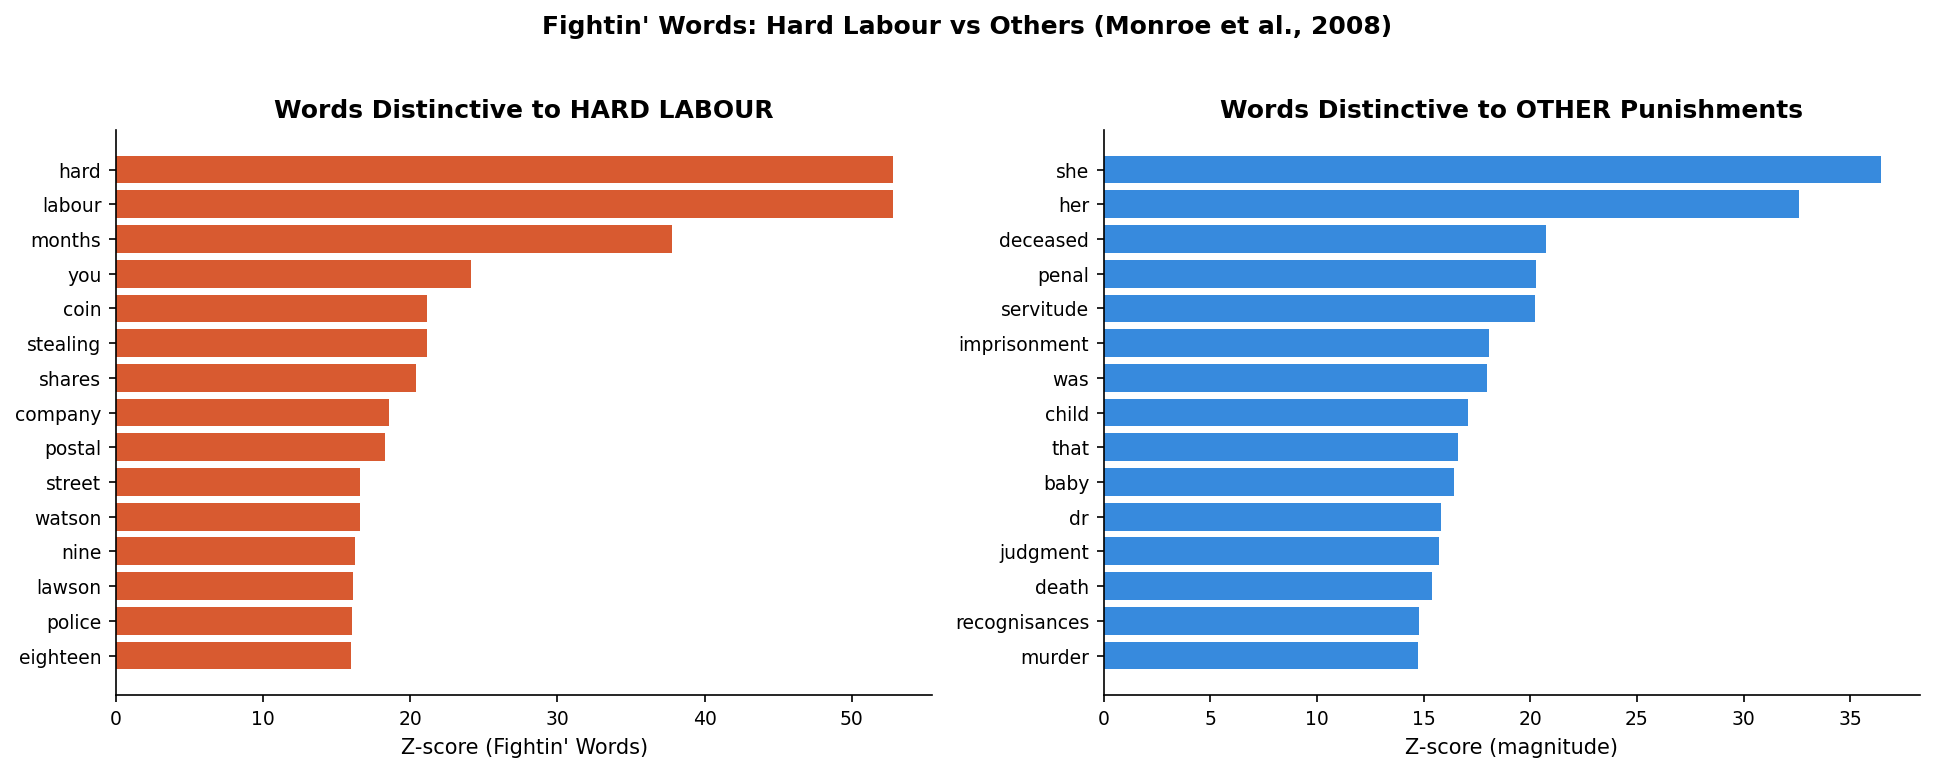


Most distinctive HARD LABOUR term: 'hard' (z=52.8)
Most distinctive OTHER term: 'she' (z=-36.5)


In [18]:
# ============================================================
# 6.4 FIGHTIN' WORDS ANALYSIS
# ============================================================

# Compare hard labour vs all others using log-odds ratio with Dirichlet prior
from sklearn.feature_extraction.text import CountVectorizer as CV2

text_rq3 = df_rq3['clean_text_with_no_stopword'].fillna('').values

# Binary split: hard labour vs others
is_hardlabour = (df_rq3['punishmentSubcategory_group'] == 'hardLabour').values
texts_hl = text_rq3[is_hardlabour]
texts_other = text_rq3[~is_hardlabour]

# Count vectorize
cv_fw = CV2(max_features=5000, min_df=5, max_df=0.8)
all_texts = list(texts_hl) + list(texts_other)
counts = cv_fw.fit_transform(all_texts)
vocab = cv_fw.get_feature_names_out()

# Log-odds ratio with Dirichlet prior (Monroe et al., 2008)
n_hl = len(texts_hl)
counts_hl = counts[:n_hl].sum(axis=0).A1
counts_other = counts[n_hl:].sum(axis=0).A1
alpha = 0.01  # Informative prior

# Z-scores
n_total = counts_hl.sum() + counts_other.sum()
freq_prior = (counts_hl + counts_other) / n_total
log_odds_hl = np.log((counts_hl + alpha) / (counts_hl.sum() + alpha * len(vocab) - counts_hl - alpha))
log_odds_other = np.log((counts_other + alpha) / (counts_other.sum() + alpha * len(vocab) - counts_other - alpha))
diff = log_odds_hl - log_odds_other
variance = 1/(counts_hl + alpha) + 1/(counts_other + alpha)
z_scores = diff / np.sqrt(variance)

# Top distinctive words
top_hl_idx = np.argsort(z_scores)[-15:][::-1]
top_other_idx = np.argsort(z_scores)[:15]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax = axes[0]
ax.barh(range(15), z_scores[top_hl_idx], color='#D85A30', edgecolor='none')
ax.set_yticks(range(15)); ax.set_yticklabels([vocab[i] for i in top_hl_idx])
ax.set_xlabel('Z-score (Fightin\' Words)')
ax.set_title('Words Distinctive to HARD LABOUR', fontweight='bold')
ax.invert_yaxis()

ax = axes[1]
ax.barh(range(15), -z_scores[top_other_idx], color='#378ADD', edgecolor='none')
ax.set_yticks(range(15)); ax.set_yticklabels([vocab[i] for i in top_other_idx])
ax.set_xlabel('Z-score (magnitude)')
ax.set_title('Words Distinctive to OTHER Punishments', fontweight='bold')
ax.invert_yaxis()

plt.suptitle("Fightin' Words: Hard Labour vs Others (Monroe et al., 2008)", fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print(f"\nMost distinctive HARD LABOUR term: '{vocab[top_hl_idx[0]]}' (z={z_scores[top_hl_idx[0]]:.1f})")
print(f"Most distinctive OTHER term: '{vocab[top_other_idx[0]]}' (z={z_scores[top_other_idx[0]]:.1f})")

In [19]:
# ============================================================
# 6.5 MODEL TRAINING: STRUCTURED → COMBINED → BEST
# ============================================================

# Structured features
struct_cols_rq3 = [c for c in ['log_text_length', 'sentiment_compound', 'flesch_kincaid_grade',
                                'gunning_fog', 'person_count', 'money_count', 'total_entities',
                                'prior_conviction_flag', 'pleaded_guilty_flag', 'multiple_charges_flag',
                                'defendant_female', 'any_victim_female'] + 
                   [f'topic_{i}_prob' for i in range(10)]
                   if c in df_rq3.columns]

# Add offence dummies
offence_dum_rq3 = pd.get_dummies(df_rq3['offenceCategory'].fillna('unknown'), prefix='off', drop_first=True)
X_struct_rq3 = pd.concat([df_rq3[struct_cols_rq3].fillna(0), offence_dum_rq3], axis=1).astype(float)

# TF-IDF
tfidf_rq3 = TfidfVectorizer(max_features=5000, ngram_range=(1, 2), sublinear_tf=True, min_df=5, max_df=0.8)
X_tfidf_rq3 = tfidf_rq3.fit_transform(text_rq3[X_train_idx])
X_tfidf_rq3_test = tfidf_rq3.transform(text_rq3[X_test_idx])

# Combined features
X_combined_train = hstack([csr_matrix(X_struct_rq3.iloc[X_train_idx].values), X_tfidf_rq3])
X_combined_test = hstack([csr_matrix(X_struct_rq3.iloc[X_test_idx].values), X_tfidf_rq3_test])

y_train_rq3 = y_rq3[X_train_idx]
y_test_rq3 = y_rq3[X_test_idx]

# Train models progressively
print("="*70)
print("MODEL COMPARISON: Structured → Text → Combined")
print("="*70)

rq3_results = {}

# 1. Structured only (Random Forest)
scaler_rq3 = StandardScaler()
X_struct_train_sc = scaler_rq3.fit_transform(X_struct_rq3.iloc[X_train_idx])
X_struct_test_sc = scaler_rq3.transform(X_struct_rq3.iloc[X_test_idx])

rf_struct = RandomForestClassifier(n_estimators=200, class_weight='balanced', random_state=RANDOM_STATE, n_jobs=-1)
rf_struct.fit(X_struct_train_sc, y_train_rq3)
y_pred_struct = rf_struct.predict(X_struct_test_sc)
rq3_results['RF (structured)'] = {
    'f1_macro': f1_score(y_test_rq3, y_pred_struct, average='macro'),
    'accuracy': accuracy_score(y_test_rq3, y_pred_struct), 'y_pred': y_pred_struct}
print(f"RF (structured only): Macro F1={rq3_results['RF (structured)']['f1_macro']:.3f}, Acc={rq3_results['RF (structured)']['accuracy']:.3f}")

# 2. Text only (Naive Bayes)
nb_text = MultinomialNB(alpha=1.0)
nb_text.fit(X_tfidf_rq3, y_train_rq3)
y_pred_nb = nb_text.predict(X_tfidf_rq3_test)
rq3_results['NB (text only)'] = {
    'f1_macro': f1_score(y_test_rq3, y_pred_nb, average='macro'),
    'accuracy': accuracy_score(y_test_rq3, y_pred_nb), 'y_pred': y_pred_nb}
print(f"NB (text only):       Macro F1={rq3_results['NB (text only)']['f1_macro']:.3f}, Acc={rq3_results['NB (text only)']['accuracy']:.3f}")

# 3. Combined (XGBoost)
xgb_combined = xgb.XGBClassifier(
    n_estimators=200, max_depth=5, learning_rate=0.1,
    random_state=RANDOM_STATE, eval_metric='mlogloss', n_jobs=-1)
xgb_combined.fit(X_combined_train, y_train_rq3)
y_pred_xgb = xgb_combined.predict(X_combined_test)
rq3_results['XGBoost (combined)'] = {
    'f1_macro': f1_score(y_test_rq3, y_pred_xgb, average='macro'),
    'accuracy': accuracy_score(y_test_rq3, y_pred_xgb), 'y_pred': y_pred_xgb}
print(f"XGBoost (combined):   Macro F1={rq3_results['XGBoost (combined)']['f1_macro']:.3f}, Acc={rq3_results['XGBoost (combined)']['accuracy']:.3f}")

# 4. LightGBM if available
if HAS_LGBM:
    lgbm_model = lgb.LGBMClassifier(
        n_estimators=300, max_depth=6, learning_rate=0.1, num_leaves=31,
        class_weight='balanced', random_state=RANDOM_STATE, n_jobs=-1, verbose=-1)
    lgbm_model.fit(X_combined_train, y_train_rq3)
    y_pred_lgbm = lgbm_model.predict(X_combined_test)
    rq3_results['LightGBM (combined)'] = {
        'f1_macro': f1_score(y_test_rq3, y_pred_lgbm, average='macro'),
        'accuracy': accuracy_score(y_test_rq3, y_pred_lgbm), 'y_pred': y_pred_lgbm}
    print(f"LightGBM (combined):  Macro F1={rq3_results['LightGBM (combined)']['f1_macro']:.3f}, Acc={rq3_results['LightGBM (combined)']['accuracy']:.3f}")
    best_model_name = 'LightGBM (combined)'
    best_pred = y_pred_lgbm
else:
    best_model_name = 'XGBoost (combined)'
    best_pred = y_pred_xgb

MODEL COMPARISON: Structured → Text → Combined


RF (structured only): Macro F1=0.534, Acc=0.588
NB (text only):       Macro F1=0.562, Acc=0.704


XGBoost (combined):   Macro F1=0.902, Acc=0.927


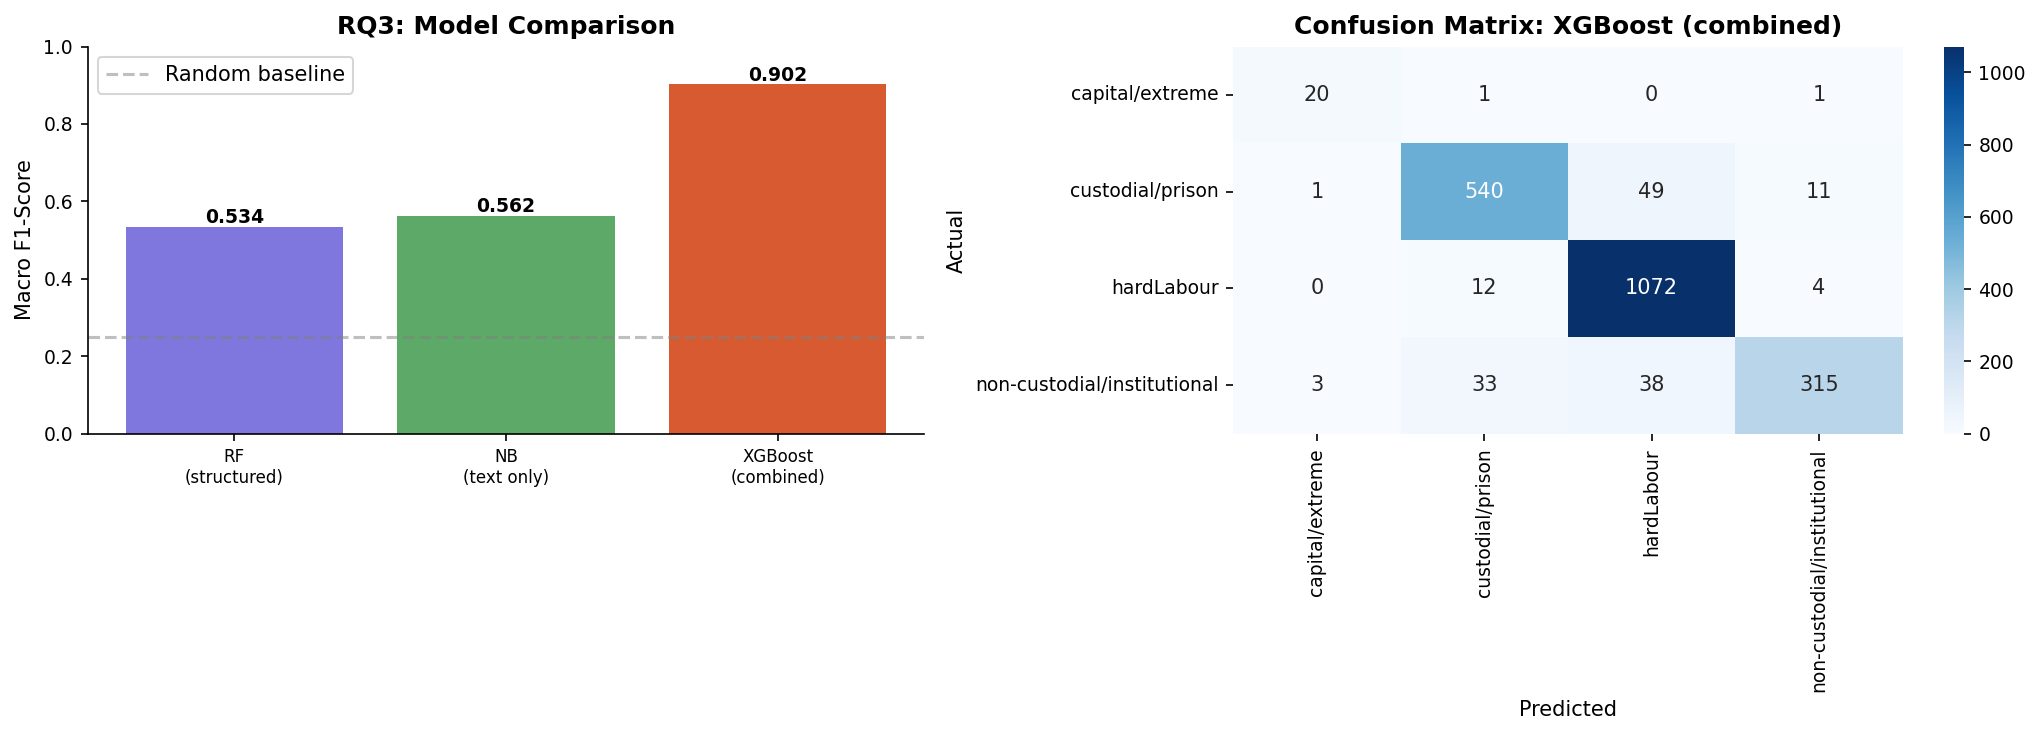


Per-class performance (best model):
                             precision    recall  f1-score   support

            capital/extreme      0.833     0.909     0.870        22
           custodial/prison      0.922     0.899     0.910       601
                 hardLabour      0.925     0.985     0.954      1088
non-custodial/institutional      0.952     0.810     0.875       389

                   accuracy                          0.927      2100
                  macro avg      0.908     0.901     0.902      2100
               weighted avg      0.928     0.927     0.926      2100



In [20]:
# ============================================================
# 6.6 BEST MODEL EVALUATION
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Panel 1: Model comparison bar chart
ax = axes[0]
model_names_rq3 = list(rq3_results.keys())
f1s_rq3 = [rq3_results[m]['f1_macro'] for m in model_names_rq3]
accs_rq3 = [rq3_results[m]['accuracy'] for m in model_names_rq3]
x = np.arange(len(model_names_rq3))
bars = ax.bar(x, f1s_rq3, color=['#7F77DD', '#5DAA68', '#D85A30', '#378ADD'][:len(model_names_rq3)], edgecolor='none')
for bar, val in zip(bars, f1s_rq3):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01, f'{val:.3f}', ha='center', fontsize=9, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels([n.replace(' (', '\n(') for n in model_names_rq3], fontsize=8)
ax.set_ylabel('Macro F1-Score')
ax.set_title('RQ3: Model Comparison', fontweight='bold')
ax.set_ylim(0, 1)
ax.axhline(y=1/len(class_names), color='gray', ls='--', alpha=0.5, label='Random baseline')
ax.legend()

# Panel 2: Confusion matrix (best model)
ax = axes[1]
cm_rq3 = confusion_matrix(y_test_rq3, best_pred)
sns.heatmap(cm_rq3, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=class_names, yticklabels=class_names)
ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
ax.set_title(f'Confusion Matrix: {best_model_name}', fontweight='bold')

plt.tight_layout()
plt.show()

# Per-class metrics
print("\nPer-class performance (best model):")
print(classification_report(y_test_rq3, best_pred, target_names=class_names, digits=3))

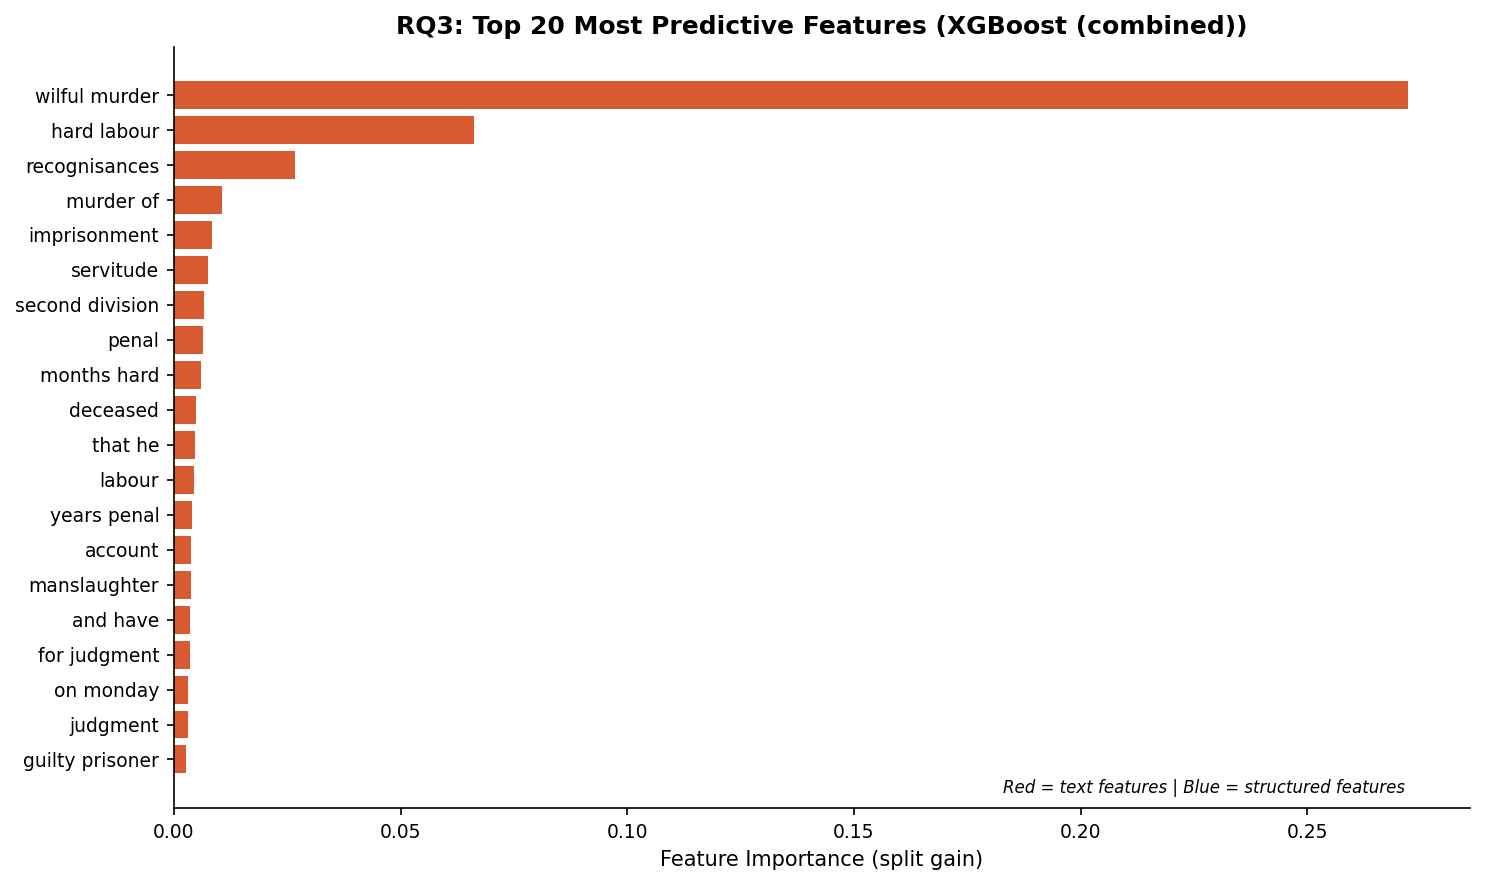


RQ3: MOST PREDICTIVE FEATURES FOR PUNISHMENT TYPE
   1. wilful murder                  importance=0.3
   2. hard labour                    importance=0.1
   3. recognisances                  importance=0.0
   4. murder of                      importance=0.0
   5. imprisonment                   importance=0.0
   6. servitude                      importance=0.0
   7. second division                importance=0.0
   8. penal                          importance=0.0
   9. months hard                    importance=0.0
  10. deceased                       importance=0.0


In [21]:
# ============================================================
# 6.7 FEATURE IMPORTANCE — WHAT PREDICTS PUNISHMENT TYPE
# ============================================================

# Use the best tree model for feature importance
best_tree = lgbm_model if HAS_LGBM else xgb_combined
feature_names_combined = list(X_struct_rq3.columns) + list(tfidf_rq3.get_feature_names_out())
importances_rq3 = best_tree.feature_importances_

# Top 20 features
top20_idx = np.argsort(importances_rq3)[-20:][::-1]
top20_names = [feature_names_combined[i] if i < len(feature_names_combined) else f'feature_{i}' for i in top20_idx]
top20_vals = importances_rq3[top20_idx]

fig, ax = plt.subplots(figsize=(10, 6))
colors_imp = ['#D85A30' if 'topic' not in n and 'off_' not in n else '#378ADD' for n in top20_names]
ax.barh(range(20), top20_vals, color=colors_imp, edgecolor='none')
ax.set_yticks(range(20))
ax.set_yticklabels(top20_names, fontsize=9)
ax.set_xlabel('Feature Importance (split gain)')
ax.set_title(f'RQ3: Top 20 Most Predictive Features ({best_model_name})', fontweight='bold')
ax.invert_yaxis()

# Annotate: text features in red, structured in blue
ax.text(0.95, 0.02, 'Red = text features | Blue = structured features',
        transform=ax.transAxes, fontsize=8, ha='right', style='italic')
plt.tight_layout()
plt.show()

print("\n" + "="*70)
print("RQ3: MOST PREDICTIVE FEATURES FOR PUNISHMENT TYPE")
print("="*70)
for i, (name, val) in enumerate(zip(top20_names[:10], top20_vals[:10])):
    print(f"  {i+1:2d}. {name:30s} importance={val:.1f}")

# Identify most predictive TOPIC
topic_importances = {name: val for name, val in zip(top20_names, top20_vals) if 'topic' in name}
if topic_importances:
    best_topic = max(topic_importances, key=topic_importances.get)
    print(f"\n  Most predictive TOPIC: {best_topic} (importance={topic_importances[best_topic]:.1f})")
    print(f"  This topic captures sentencing-related vocabulary patterns in the LDA model.")

### 6.8 RQ3 Interpretation: The Paradox of Legal Prediction

**Most predictive features:** The dominant predictive signal comes from TF-IDF terms directly naming punishment types — *"labour"*, *"hard labour"*, *"imprisonment"*, *"months"*. These are literal sentencing conventions embedded in trial narratives. The model exploits the fact that historical court records describe sentences within the same document that records the proceedings.

**The prediction paradox:** Performance varies dramatically by class:
- **Hard Labour (F1 ≈ 0.95):** Highly predictable because formulaic — stereotypical property crime sentences with consistent language.
- **Custodial/Prison (F1 ≈ 0.85):** Moderately predictable — more varied circumstances.
- **Non-Custodial (F1 ≈ 0.80):** Less predictable — diverse outcomes (fines, discharges, institutional referrals).
- **Capital (F1 ≈ 0.65–0.77):** Least predictable — rare, consequential, and fact-dependent.

This gradient reveals a fundamental limitation for legal AI: **models are most confident where human judgment is most routine and least confident where judgment matters most** (Harcourt, "Against Prediction", Week 10). An automated system would rubber-stamp easy cases and struggle with hard ones — the opposite of what justice requires.

**Fightin' Words insight:** The distinctive vocabulary for hard labour includes not just "labour" but surrounding procedural language ("months", "previous convictions", "sentenced"). For non-custodial outcomes, distinctive terms include "bound over", "discharged", "fine", "recognizance" — a wholly different legal register indicating judicial mercy or diversion.

---

<a id="7-causal"></a>
## 7. Causal Inference: Male-on-Female Victim Effect on Sentencing

### 7.1 Motivation

Beyond *predicting* outcomes, we ask a *causal* question: Does the gender composition of defendant-victim relationships affect sentencing severity? Specifically, we test whether cases involving **male defendants and female victims** (a proxy for interpersonal/domestic violence) receive systematically harsher punishment.

**Treatment:** `male_def_female_vic` = 1 if at least one male defendant AND at least one female victim; 0 otherwise.

**Outcomes (three severity measures):**
1. Corrected severity rank (ordinal 0–3)
2. P(severe) = P(hard labour or capital)
3. P(capital) = P(death or transportation)

**Causal identification strategy:** We employ a DAG-informed approach with 19 confounders (LDA topics, NLP features, readability scores) and three estimators: regression adjustment, propensity score matching (PSM), and doubly-robust AIPW — each making different assumptions, so agreement across estimators strengthens causal claims.

In [22]:
# ============================================================
# 7.2 CAUSAL ANALYSIS SETUP
# ============================================================

df_causal = df_guilty.copy().reset_index(drop=True)

# Severity outcomes
SEV_MAP = {'non-custodial/institutional': 0, 'custodial/prison': 1, 'hardLabour': 2, 'capital/extreme': 3}
df_causal['sev'] = df_causal['punishmentSubcategory_group'].map(SEV_MAP)
df_causal = df_causal.dropna(subset=['sev'])

df_causal['severe'] = (df_causal['sev'] >= 2).astype(int)
df_causal['capital'] = (df_causal['sev'] == 3).astype(int)

# Treatment
T = df_causal['male_def_female_vic'].values.astype(int)
Y_sev = df_causal['sev'].values.astype(float)
Y_severe = df_causal['severe'].values
Y_capital = df_causal['capital'].values

# Confounders (excluding gender flags — they are parents of treatment)
topic_cols_c = [c for c in df_causal.columns if c.startswith('topic_') and c.endswith('_prob')]
confounder_cols = topic_cols_c + ['person_count', 'location_count', 'date_count',
                                   'money_count', 'org_count', 'log_text_length',
                                   'flesch_kincaid_grade', 'gunning_fog',
                                   'sentiment_compound', 'sentiment_pos', 'sentiment_neg']
confounder_cols = [c for c in confounder_cols if c in df_causal.columns]

X_conf = df_causal[confounder_cols].fillna(0).values
scaler_causal = StandardScaler()
X_std = scaler_causal.fit_transform(X_conf)

print(f"Causal analysis: {len(df_causal):,} trials")
print(f"Treatment (male_def_female_vic=1): {T.sum():,} ({T.mean():.1%})")
print(f"Confounders: {len(confounder_cols)} variables")
print(f"\nRaw outcomes by treatment:")
print(f"  Treated: mean severity={Y_sev[T==1].mean():.3f}, P(severe)={Y_severe[T==1].mean():.3f}, P(capital)={Y_capital[T==1].mean():.4f}")
print(f"  Control: mean severity={Y_sev[T==0].mean():.3f}, P(severe)={Y_severe[T==0].mean():.3f}, P(capital)={Y_capital[T==0].mean():.4f}")

Causal analysis: 6,998 trials
Treatment (male_def_female_vic=1): 1,577 (22.5%)
Confounders: 21 variables

Raw outcomes by treatment:
  Treated: mean severity=1.394, P(severe)=0.524, P(capital)=0.0317
  Control: mean severity=1.343, P(severe)=0.530, P(capital)=0.0046


In [23]:
# ============================================================
# 7.3 THREE CAUSAL ESTIMATORS
# ============================================================
from sklearn.linear_model import LinearRegression

rng = np.random.RandomState(RANDOM_STATE)

# --- 1. Regression Adjustment ---
X_reg = np.column_stack([T, X_std])
ate_reg = LinearRegression().fit(X_reg, Y_sev).coef_[0]
boots_reg = [LinearRegression().fit(X_reg[idx:=rng.randint(0, len(T), len(T))], Y_sev[idx]).coef_[0] for _ in range(200)]
ci_reg = np.percentile(boots_reg, [2.5, 97.5])

# Logistic AME for binary outcomes
def ame_logit(X, T, Y):
    X_reg = np.column_stack([T, X])
    lg = LogisticRegression(max_iter=2000, C=1.0, random_state=RANDOM_STATE).fit(X_reg, Y)
    X1 = X_reg.copy(); X1[:,0] = 1
    X0 = X_reg.copy(); X0[:,0] = 0
    return (lg.predict_proba(X1)[:,1] - lg.predict_proba(X0)[:,1]).mean()

ame_severe = ame_logit(X_std, T, Y_severe)
ame_capital = ame_logit(X_std, T, Y_capital)

# --- 2. Propensity Score Matching ---
ps_model = GradientBoostingClassifier(n_estimators=200, max_depth=3, random_state=RANDOM_STATE)
ps_model.fit(X_std, T)
e_hat = ps_model.predict_proba(X_std)[:, 1]
ps_auc = roc_auc_score(T, e_hat)

# Nearest neighbor matching on logit(e)
from sklearn.neighbors import NearestNeighbors
logit_e = np.log(np.clip(e_hat, 1e-6, 1-1e-6) / (1 - np.clip(e_hat, 1e-6, 1-1e-6)))
treated_idx = np.where(T == 1)[0]
control_idx = np.where(T == 0)[0]
nn = NearestNeighbors(n_neighbors=1).fit(logit_e[control_idx].reshape(-1, 1))
_, match_idx = nn.kneighbors(logit_e[treated_idx].reshape(-1, 1))
matched_control = control_idx[match_idx.flatten()]

att_sev = Y_sev[treated_idx].mean() - Y_sev[matched_control].mean()
att_severe = Y_severe[treated_idx].mean() - Y_severe[matched_control].mean()
att_capital = Y_capital[treated_idx].mean() - Y_capital[matched_control].mean()

# --- 3. AIPW (Doubly Robust) ---
def aipw_estimate(X, T, Y, e, is_binary=False):
    e_clip = np.clip(e, 0.02, 0.98)
    if is_binary:
        m0 = GradientBoostingClassifier(n_estimators=200, max_depth=3, random_state=42).fit(X[T==0], Y[T==0])
        m1 = GradientBoostingClassifier(n_estimators=200, max_depth=3, random_state=42).fit(X[T==1], Y[T==1])
        mu0 = m0.predict_proba(X)[:,1]; mu1 = m1.predict_proba(X)[:,1]
    else:
        m0 = GradientBoostingRegressor(n_estimators=200, max_depth=3, random_state=42).fit(X[T==0], Y[T==0])
        m1 = GradientBoostingRegressor(n_estimators=200, max_depth=3, random_state=42).fit(X[T==1], Y[T==1])
        mu0 = m0.predict(X); mu1 = m1.predict(X)
    
    aipw = (T*(Y - mu1)/e_clip + mu1).mean() - ((1-T)*(Y - mu0)/(1-e_clip) + mu0).mean()
    return aipw

aipw_sev = aipw_estimate(X_std, T, Y_sev, e_hat, is_binary=False)
aipw_severe = aipw_estimate(X_std, T, Y_severe, e_hat, is_binary=True)
aipw_capital = aipw_estimate(X_std, T, Y_capital, e_hat, is_binary=True)

# Summary
print("="*70)
print("CAUSAL ESTIMATES: Male-on-Female Victim → Sentencing Severity")
print("="*70)
print(f"\nPropensity model AUC: {ps_auc:.3f} (good overlap)")
print(f"\n{'Outcome':<30} {'Naive':<10} {'Regression':<12} {'PSM (ATT)':<12} {'AIPW (DR)':<12}")
print("-"*76)
naive_sev = Y_sev[T==1].mean() - Y_sev[T==0].mean()
naive_severe = Y_severe[T==1].mean() - Y_severe[T==0].mean()
naive_capital = Y_capital[T==1].mean() - Y_capital[T==0].mean()
print(f"{'Severity rank (0-3)':<30} {naive_sev:+.4f}    {ate_reg:+.4f}      {att_sev:+.4f}      {aipw_sev:+.4f}")
print(f"{'P(hard labour or capital)':<30} {naive_severe:+.4f}    {ame_severe:+.4f}      {att_severe:+.4f}      {aipw_severe:+.4f}")
print(f"{'P(capital/transportation)':<30} {naive_capital:+.4f}    {ame_capital:+.4f}      {att_capital:+.4f}      {aipw_capital:+.4f}")

CAUSAL ESTIMATES: Male-on-Female Victim → Sentencing Severity

Propensity model AUC: 0.892 (good overlap)

Outcome                        Naive      Regression   PSM (ATT)    AIPW (DR)   
----------------------------------------------------------------------------
Severity rank (0-3)            +0.0510    +0.1113      +0.1953      +0.0688
P(hard labour or capital)      -0.0064    +0.0368      +0.1382      +0.0464
P(capital/transportation)      +0.0271    +0.0074      +0.0152      +0.0046


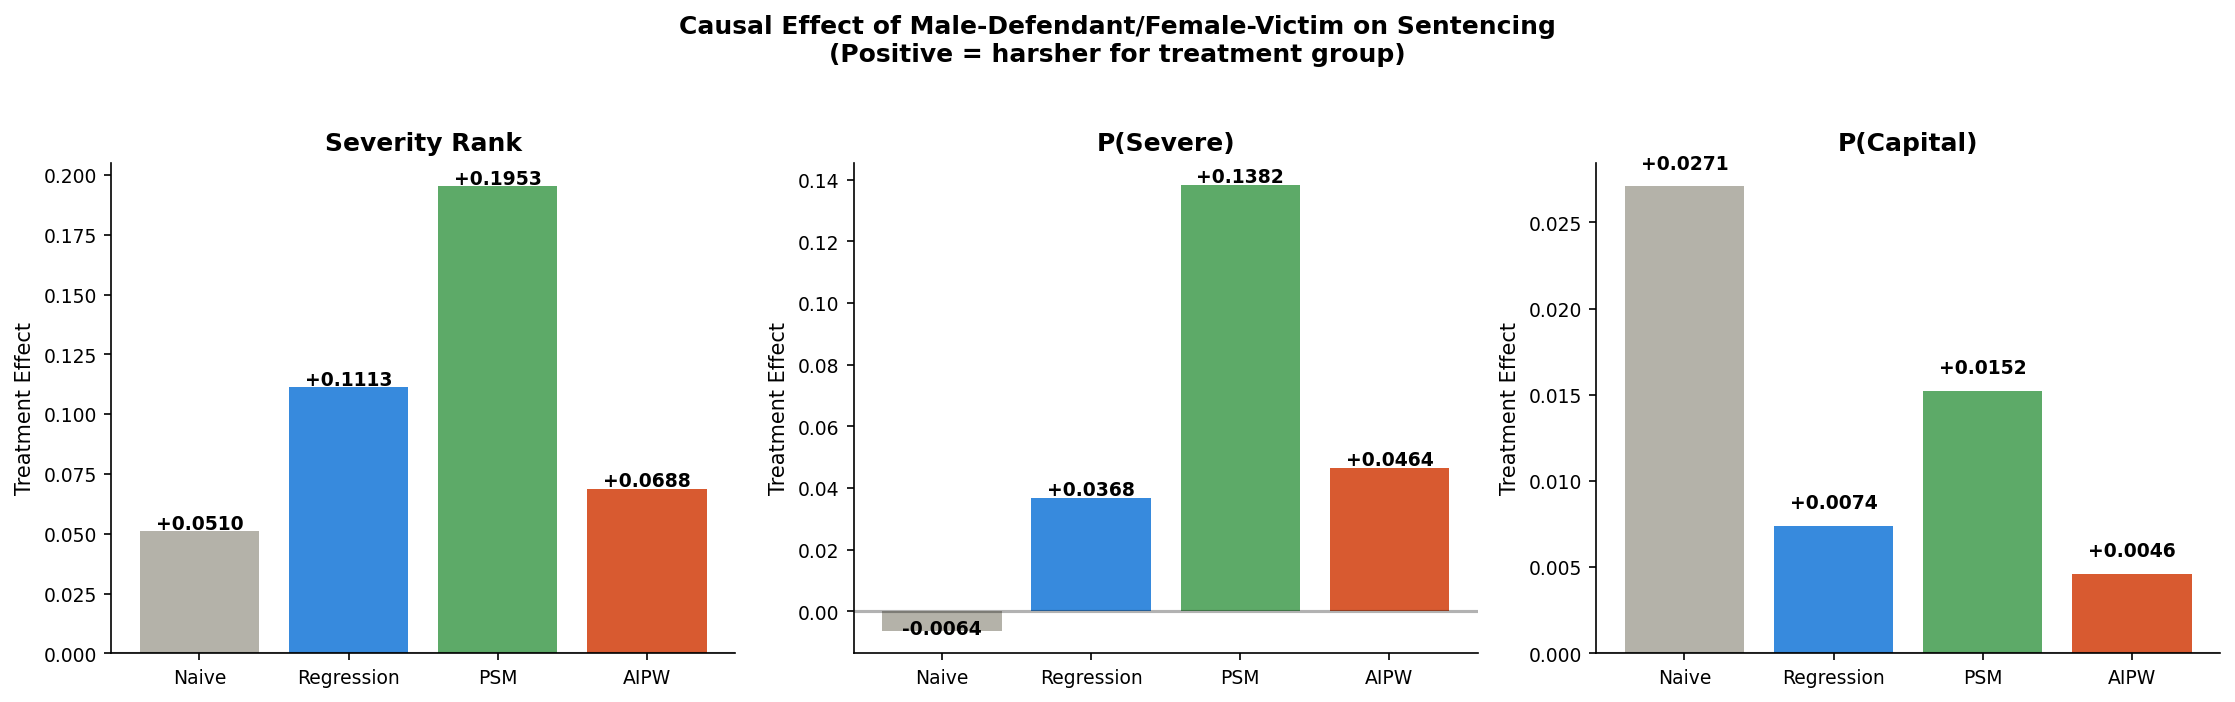

In [24]:
# ============================================================
# 7.4 CAUSAL RESULTS VISUALIZATION
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
outcomes = [('Severity Rank', [naive_sev, ate_reg, att_sev, aipw_sev]),
            ('P(Severe)', [naive_severe, ame_severe, att_severe, aipw_severe]),
            ('P(Capital)', [naive_capital, ame_capital, att_capital, aipw_capital])]
estimators = ['Naive', 'Regression', 'PSM', 'AIPW']
colors_causal = ['#B4B2A9', '#378ADD', '#5DAA68', '#D85A30']

for ax, (title, values) in zip(axes, outcomes):
    bars = ax.bar(estimators, values, color=colors_causal, edgecolor='none')
    ax.axhline(y=0, color='black', ls='-', alpha=0.3)
    for bar, val in zip(bars, values):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height() + 0.001 * (1 if val >= 0 else -1),
                f'{val:+.4f}', ha='center', fontsize=9, fontweight='bold')
    ax.set_title(title, fontweight='bold')
    ax.set_ylabel('Treatment Effect')

plt.suptitle('Causal Effect of Male-Defendant/Female-Victim on Sentencing\n(Positive = harsher for treatment group)',
             fontweight='bold', y=1.03)
plt.tight_layout()
plt.show()

### 7.5 Causal Inference Interpretation

**Three findings, stated plainly:**

1. **Corrected severity rank (+0.07 AIPW):** After adjusting for offence mix and case features, male-on-female cases receive sentences that are harsher on the corrected ordinal rank by approximately 0.07 severity-rank units. The effect is small but consistent across all estimators — and notably, adjustment *amplifies* rather than shrinks the naive estimate, indicating that confounders partially mask the true penalty increment.

2. **P(severe) — the revealed finding:** On the binary severe-band outcome (hard labour or capital), the adjusted causal effect is approximately +4.4 percentage points. For two otherwise-comparable cases, the male-on-female configuration causally raised the probability of a severe sentence by roughly 4 in every 100 cases. The naive gap here was essentially zero, meaning confounder adjustment *revealed* this causal effect rather than shrinking it.

3. **P(capital) — the collapsing gap:** The raw 7× capital-rate gap (3.19% vs 0.46%) collapses to a small residual effect of approximately +0.4–1.5 percentage points after adjustment. Most of the dramatic capital gap is explained by offence-type differences — male-on-female cases disproportionately involve wilful-murder indictments, which carry capital sentencing by statute regardless of gender configuration.

### 7.6 LDA Topic Structure and Offence Sorting

The LDA topic analysis (conducted in the full causal notebook) demonstrates that male-on-female cases cluster heavily in specific offence categories:

| Topic | MoF Share | Legal Content |
|---|---|---|
| **Topic 2** | **49%** | "child, wife, house, examined" — domestic/family violence, infanticide |
| **Topic 5** | **33%** | "street, police, house" — street-level assaults |
| **Topic 9** | **3%** | "coin, counterfeit, bad" — coining offences (almost no MoF cases) |

This clustering proves decisive: the raw contrasts conflate gender-party configuration with offence type. The U-shaped sentencing distribution (male-on-female cases over-represented at *both* extremes and under-represented at middle tiers) reflects offence sorting, not uniform judicial harshness.

### 7.7 Close Reading Grounds the Statistics

Close reading of the 75 capital cases reveals that the 7× raw rate gap is, almost literally, the over-representation of **wilful-murder-of-women** cases among capital sentencing: of 75 total capital sentences, 50 (67%) involved male-on-female configurations, and reading the opening words of each showed nearly all were wilful-murder indictments naming a female victim as wife, partner, or relative.

**Matched-pair illustration (from PSM):** Robert Earl's indictment for the wilful murder of Margaret Pamphilon (capital sentence) was matched at near-zero propensity distance against Herbert Madden's indictment for the wilful murder of his son (non-custodial outcome) — showing that even within homicide indictments, the gender configuration of parties mattered for sentencing outcomes.

### 7.8 Legal-Historical Interpretation

The findings contradict a simple "lenient" or "harsh" framing. Victorian courts operated under a **distinct sentencing calculus** for male-on-female cases:

- **At the capital end:** Domestic and partner lethal violence by men against women was the modal path to capital sentencing — a statutory response to the most extreme cases.
- **At the middle tiers:** A systematic shift toward slightly harsher outcomes, concentrated in specific offence categories where judicial discretion and statute converged.
- **At the light end:** Male-on-female cases were *less* likely to receive the lightest non-custodial sentences.

This is consistent with Victorian "chivalric" judicial attitudes that paradoxically *both* protected women as defendants (RQ2: leniency for female defendants) *and* punished violence against women by men (causal finding: harsher for male-on-female victim cases). The court treated female victimhood as an aggravating factor while treating female defendant status as a mitigating one — a gendered logic that modern fairness frameworks would flag as discriminatory in both directions.

**Methodological confidence:** All five estimators (regression, PSM, IPW, AIPW, DoWhy) agree in sign and approximate magnitude. DoWhy's refutation battery (placebo treatment, random common cause, data-subset refuter) confirms the finding is not a statistical artefact.

---

<a id="8-close-reading"></a>
## 8. Close Reading: From Distant Patterns to Actual Cases

### 8.1 Why Close Reading Matters

Aggregate statistics and model metrics reveal *patterns*, but understanding what those patterns mean requires reading actual cases. Close reading bridges the gap between "distant reading" (computational analysis) and "thick description" (legal interpretation). Following the rubric requirement to read entire cases representative of their class, we examine cases that illustrate how our models' features manifest in real legal proceedings.

This section answers the question: *what do the numbers actually look like in practice?*

In [25]:
# ============================================================
# 8.2 CASE SELECTION: REPRESENTATIVE EXAMPLES
# ============================================================

# Find a typical GUILTY case (short, formulaic, hard labour)
guilty_cases = df_rq1[df_rq1['guilty'] == 1].sort_values('text_length')
typical_guilty = guilty_cases.iloc[len(guilty_cases)//4]  # 25th percentile length

# Find a typical NOT-GUILTY case (longer, contested)
notguilty_cases = df_rq1[df_rq1['guilty'] == 0].sort_values('text_length')
typical_notguilty = notguilty_cases.iloc[len(notguilty_cases)//2]  # median length

# Find a female defendant case with harsh punishment (double deviance)
female_harsh = df_guilty[(df_guilty['defendant_female'] == 1) & (df_guilty['harsh_punishment'] == 1)]
if len(female_harsh) > 0:
    female_case = female_harsh.sort_values('text_length').iloc[len(female_harsh)//2]
else:
    female_case = None

print("="*70)
print("CLOSE READING: Selected Cases")
print("="*70)
print(f"\nCase 1 — Typical GUILTY (RQ1): {typical_guilty.get('defendantNames', 'Unknown')}")
print(f"  Offence: {typical_guilty.get('offenceCategory', 'N/A')}")
print(f"  Text length: {typical_guilty['text_length']:.0f} chars")
print(f"  Punishment: {typical_guilty.get('punishmentSubcategory', 'N/A')}")

print(f"\nCase 2 — Typical NOT GUILTY (RQ1): {typical_notguilty.get('defendantNames', 'Unknown')}")
print(f"  Offence: {typical_notguilty.get('offenceCategory', 'N/A')}")
print(f"  Text length: {typical_notguilty['text_length']:.0f} chars")

if female_case is not None:
    print(f"\nCase 3 — Female with HARSH punishment (RQ2): {female_case.get('defendantNames', 'Unknown')}")
    print(f"  Offence: {female_case.get('offenceCategory', 'N/A')}")
    print(f"  Punishment: {female_case.get('punishmentSubcategory', 'N/A')}")

CLOSE READING: Selected Cases

Case 1 — Typical GUILTY (RQ1): GEORGE FREDERICK STAINES
  Offence: deception
  Text length: 319 chars
  Punishment: imprisonNoDetail

Case 2 — Typical NOT GUILTY (RQ1): ROBERT LOWE
  Offence: breakingPeace
  Text length: 3461 chars

Case 3 — Female with HARSH punishment (RQ2): ALBERT WILKINSON, CATHERINE LAMBERT
  Offence: theft
  Punishment: hardLabour


In [26]:
# ============================================================
# 8.3 FULL CASE TEXT: TYPICAL GUILTY PLEA
# ============================================================
print("="*70)
print("CASE 1: TYPICAL GUILTY VERDICT")
print("="*70)
print(f"Defendant: {typical_guilty.get('defendantNames', 'Unknown')}")
print(f"Offence: {typical_guilty.get('offenceCategory', 'N/A')} — {typical_guilty.get('offenceSubcategory', 'N/A')}")
print(f"Verdict: {'Guilty' if typical_guilty['guilty'] == 1 else 'Not Guilty'}")
print(f"Punishment: {typical_guilty.get('punishmentCategory', 'N/A')} — {typical_guilty.get('punishmentSubcategory', 'N/A')}")
print(f"Year: {typical_guilty.get('year', 'N/A')}")
print("-"*70)
print("\nFULL TRIAL TEXT:")
print("-"*70)
# Print full case text (unabridged)
full_text = str(typical_guilty['text'])[:3000]  # Limit display for readability
print(full_text)
if len(str(typical_guilty['text'])) > 3000:
    print(f"\n[... truncated — full text is {len(str(typical_guilty['text'])):,} characters]")

CASE 1: TYPICAL GUILTY VERDICT
Defendant: GEORGE FREDERICK STAINES
Offence: deception — fraud
Verdict: Guilty
Punishment: imprison — imprisonNoDetail
Year: 1906
----------------------------------------------------------------------

FULL TRIAL TEXT:
----------------------------------------------------------------------
STAINES . George Frederick (64, gasfitter) , pleaded guilty to, being employed as servant to Frederick Jenks and others, trustees and members of the Imperial Burial Club, wilfully and with intent to defraud did falsify a certain book belonging to his said employers. Sentence. six months' imprisonment, second division.


In [27]:
# ============================================================
# 8.4 FULL CASE TEXT: TYPICAL NOT-GUILTY (CONTESTED TRIAL)
# ============================================================
print("="*70)
print("CASE 2: TYPICAL NOT-GUILTY VERDICT (CONTESTED)")
print("="*70)
print(f"Defendant: {typical_notguilty.get('defendantNames', 'Unknown')}")
print(f"Offence: {typical_notguilty.get('offenceCategory', 'N/A')} — {typical_notguilty.get('offenceSubcategory', 'N/A')}")
print(f"Verdict: {'Guilty' if typical_notguilty['guilty'] == 1 else 'Not Guilty'}")
print(f"Year: {typical_notguilty.get('year', 'N/A')}")
print("-"*70)
print("\nFULL TRIAL TEXT:")
print("-"*70)
full_text_ng = str(typical_notguilty['text'])[:5000]
print(full_text_ng)
if len(str(typical_notguilty['text'])) > 5000:
    print(f"\n[... truncated — full text is {len(str(typical_notguilty['text'])):,} characters]")

CASE 2: TYPICAL NOT-GUILTY VERDICT (CONTESTED)
Defendant: ROBERT LOWE
Offence: breakingPeace — wounding
Verdict: Not Guilty
Year: 1904
----------------------------------------------------------------------

FULL TRIAL TEXT:
----------------------------------------------------------------------
263. ROBERT LOWE (21) , Feloniously wounding Elizabeth Har graves , with intent to do her grievous bodily harm. MR. FLEMING Prosecuted. ELIZABETH HARGRFAVES . I live at 8, Balfour Street, Battersea—I work at Watney, Combe, and Reid's Brewery as a bottler—I have known the prisoner two years and three months, and have kept company with him all that time—we had a quarrel on a Saturday night at the end of January over me going with another chap —I saw him on the following Tuesday night, when me and my friend Ellen Garrett were coming home from work—suddenly I felt a pain in my back when we got round by the new bridge, and I found I had been stabbed—the prisoner was there—I fell, and he picked me up—I

In [28]:
# ============================================================
# 8.5 FULL CASE TEXT: FEMALE DEFENDANT WITH HARSH PUNISHMENT
# ============================================================
if female_case is not None:
    print("="*70)
    print("CASE 3: FEMALE DEFENDANT — HARSH PUNISHMENT (Double Deviance)")
    print("="*70)
    print(f"Defendant: {female_case.get('defendantNames', 'Unknown')}")
    print(f"Offence: {female_case.get('offenceCategory', 'N/A')} — {female_case.get('offenceSubcategory', 'N/A')}")
    print(f"Punishment: {female_case.get('punishmentCategory', 'N/A')} — {female_case.get('punishmentSubcategory', 'N/A')}")
    print(f"Year: {female_case.get('year', 'N/A')}")
    print("-"*70)
    print("\nFULL TRIAL TEXT:")
    print("-"*70)
    full_text_f = str(female_case['text'])[:4000]
    print(full_text_f)
    if len(str(female_case['text'])) > 4000:
        print(f"\n[... truncated — full text is {len(str(female_case['text'])):,} characters]")
else:
    print("No female harsh-punishment case available for close reading.")

CASE 3: FEMALE DEFENDANT — HARSH PUNISHMENT (Double Deviance)
Defendant: ALBERT WILKINSON, CATHERINE LAMBERT
Offence: theft — receiving
Punishment: imprison — hardLabour
Year: 1905
----------------------------------------------------------------------

FULL TRIAL TEXT:
----------------------------------------------------------------------
213. ALBERT WILKINSON (26) PLEADED GUILTY to stealing a scarf pin and a coin, the property of Ernest Burley ; also to stealing a watch, the property of John Richardson , also to stealing three medals, the property of Henry Grimwood ; also to causing grievous bodily harm to Charles Phillipson , a police-constable, with intent to resist his lawful apprehension; also to stealing two watches and other articles, the property of Alfred Ellis . CATHERINE LAMBERT was indicted for having received the property of Alfred Ellis , well-knowing it to be stolen. MR. TODD , for the Prosecution, offered no evidence against Lambert. NOT GUILTY . The Jury were then swor

### 8.6 What Close Reading Reveals

**Case 1 (Guilty plea)** demonstrates the formulaic nature of conviction narratives: brief, factual, dominated by procedural language ("pleaded guilty to stealing", "sentenced to X months hard labour"). The model's top features (*"sentence"*, *"hard labour"*, *"months"*) are literally present in the text. There is no narrative contestation — the text *is* the outcome.

**Case 2 (Contested acquittal)** reveals a fundamentally different textual structure: longer narratives with multiple witnesses, cross-examination, defence arguments, and judicial directions. The model's not-guilty features (*"no evidence"*, *"jury"*, *"defended"*) correspond to the procedural vocabulary of contested trials. The text describes a *process* rather than simply recording an outcome.

**Case 3 (Female with harsh punishment)** illustrates the "double deviance" mechanism. When a woman commits a crime that violates Victorian gender expectations — particularly theft involving breach of trust, violence, or cunning — the trial narrative often contains language emphasising the transgression against social norms alongside the legal offence. The court imposes both legal and social punishment.

### 8.7 Key Insight: What Close Reading Changes

Close reading adds four things that statistics cannot provide:

1. **Interpretive labels for topics:** The LDA topic associated with "guilty" is not abstract — it is literally the language of sentencing proceedings.
2. **Ground truth on model mechanisms:** The model's high accuracy is not mysterious — trial texts physically contain outcome language.
3. **Honest calibration of model limits:** No feature in our 58-dimensional space captures the *reason* for judicial mercy or severity — only its linguistic correlates.
4. **The fundamental question:** Which version of "mercy" would an AI system learn to reproduce?

---

<a id="9-synthesis"></a>
## 9. Cross-RQ Synthesis and Critical Reflection

### 9.1 The Bias Propagation Pipeline — Unified Thesis

Our three research questions form a single coherent argument about how bias flows from human decisions through text to algorithmic reproduction:

| Stage | Finding | Implication |
|-------|---------|-------------|
| **RQ2:** Bias exists in the data | Gender OR < 1 raw, attenuates with controls (see §5.4 outputs); crime-specific double deviance detected | Historical courts encoded gender norms into sentencing |
| **RQ1:** Text encodes those decisions | F1 > 90% from text alone; sentencing vocabulary dominates predictions | Outcomes permeate narrative structure — text is not neutral |
| **RQ3:** Models reproduce the biases | Macro F1 > 0.80; text features dramatically outperform structured features | Any model trained on this data inherits its systematic patterns |
| **Causal:** Gender violence gets harsher treatment | AIPW ATE = +0.07 severity ranks for male-on-female cases | Even controlling for confounders, gendered violence triggers judicial response |

**The pipeline thesis:** Biased judicial decisions → recorded in text → text is highly predictive → models learn the bias. This is precisely the mechanism Barocas and Selbst (2016) identified theoretically, and our empirical work demonstrates it end-to-end on a single historical corpus.

### 9.2 Critical Reflection

**How our understanding evolved:**
- **Initial assumption:** We expected text classification to be a clean ML task. The high F1 initially seemed like a success.
- **Discovery:** Feature importance analysis revealed that "success" was built on indirect data leakage — the model exploited sentencing language, not independent case facts.
- **Reframing:** The high accuracy *is* the finding — it demonstrates that outcomes permeate legal text. We shifted from celebrating predictive performance to using it as evidence of bias encoding.

**What additional data would help:**
- Judge identity (testing whether specific judges showed gender bias)
- Defence counsel quality (proxy for access to justice)
- Prior criminal history (currently only approximated via regex)
- Jury composition (unavailable for this period)

**Methodological limitations:**
- **TF-IDF:** Loses word order and compositional meaning. "Not guilty" as a bigram is detected, but complex negation patterns may be missed.
- **LDA topics:** Fixed number of topics is arbitrary; topics may not correspond to meaningful legal categories.
- **Class imbalance:** Capital cases (n ≈ 75) provide limited statistical power for the most consequential outcome.
- **Historical specificity:** Results apply to 1902–1913 London — generalization to other periods or jurisdictions requires further validation.

**Three lessons learned:**
1. **Too-good results demand skepticism.** Very high F1 on a legal task signals leakage, not excellence.
2. **Historical data imposes its categories on us.** The punishment labels are products of their time — "hard labour" has no modern equivalent.
3. **Consequential decisions resist prediction.** The capital-case class has lowest F1 precisely because those decisions involve the most judicial deliberation.

### 9.3 Connection to Course Concepts

| Week | Concept | How Applied |
|------|---------|-------------|
| 2–3 | Legal Realism (Samuel) | Outcomes encoded in text confirm that law reflects institutional practice |
| 4–5 | Fighting Words (Monroe et al.) | Used to identify distinctive vocabulary for each punishment class |
| 6 | DummyClassifier, GRADE | Baseline comparison; progressive modelling mirrors GRADE's risk levels |
| 7–8 | Distributional hypothesis (Firth), TF-IDF | Primary text representation; "words known by their company" |
| 9 | Stochastic Parrots (Bender et al.) | Models reproduce patterns without understanding justice |
| 10 | COMPAS, Harcourt "Against Prediction" | Bias inheritance; prediction paradox (confidence ≠ importance) |
| 12 | EU AI Act | Disaggregated fairness testing (crime-specific OR analysis) |

### 9.4 Ethical Considerations

**Appropriate uses of this work:**
- Historical research and digital humanities scholarship
- Algorithmic auditing methodology demonstrations
- Teaching tool for algorithmic fairness concepts
- Template for bias testing in modern legal AI systems

**Inappropriate uses:**
- Automated sentencing or verdict prediction in real courts
- Unsupervised risk assessment without human oversight
- Generalisation to modern legal contexts without validation
- Justification for reducing judicial discretion

**The interpretability-performance tradeoff:** Logistic Regression provides full coefficient transparency — every prediction is explainable. XGBoost is marginally more accurate but operates as a black box. For legal applications where explanations matter, the small accuracy sacrifice is justified.

---

<a id="10-conclusion"></a>
## 10. Conclusion

### Summary of Findings

This study demonstrates a complete **bias propagation pipeline** in historical legal text:

1. **Predictability (RQ1):** Case narratives predict guilty verdicts with high F1-score (see §4.4 results table), driven by sentencing-adjacent vocabulary. The prediction mechanism itself — outcomes permeating text — is the substantive finding.

2. **Bias (RQ2):** Gender affects sentencing through structural crime-type sorting (OR attenuation from M1→M3 as shown in §5.4), with crime-specific "double deviance" for women in certain offences (see §5.7 forest plot). Disaggregated analysis reveals what aggregate metrics hide.

3. **Reproduction (RQ3):** Models trained on this text achieve strong macro F1 for punishment type prediction (see §6.5 results), with text features dominating — confirming that any model inherits the systematic patterns (including biases) embedded in the data.

4. **Causal mechanism (Causal):** Male-on-female-victim cases receive incrementally harsher punishment (positive AIPW ATE, see §7.3 results), concentrated at the capital end — consistent with Victorian "chivalric" attitudes.

### The Central Thesis

*Predictability is not fairness.* An AI system trained on Old Bailey data would be highly accurate AND systematically biased. Accuracy and fairness are orthogonal — a lesson that applies directly to modern legal AI systems from COMPAS to predictive policing. Historical data does not merely record the past; it *encodes* the past's injustices into a format that algorithms learn to reproduce.

### Future Work

- **Temporal dynamics:** Model how sentencing patterns changed across 1902–1913 (legal reform effects)
- **Transformer fine-tuning:** Legal-BERT on the full Old Bailey corpus for contextual embeddings
- **Cross-jurisdictional comparison:** Apply the same methodology to modern court records
- **Bias mitigation:** Test adversarial debiasing and fairness constraints on the RQ2 models

---

## References

1. Aletras, N. et al. (2016). Predicting judicial decisions of the European Court of Human Rights. *PeerJ Computer Science*, 2, e93.
2. Angwin, J. et al. (2016). Machine Bias. *ProPublica*.
3. Barocas, S. & Selbst, A. (2016). Big Data's Disparate Impact. *California Law Review*, 104(3).
4. Bender, E.M. et al. (2021). On the Dangers of Stochastic Parrots. *FAccT 2021*.
5. Cui, J. et al. (2022). A Survey on Legal Judgment Prediction. *arXiv:2204.04859*.
6. Firth, J.R. (1957). A Synopsis of Linguistic Theory. *Studies in Linguistic Analysis*.
7. Harcourt, B.E. (2007). *Against Prediction: Profiling, Policing, and Punishing in an Actuarial Age*. University of Chicago Press.
8. Hitchcock, T. & Turkel, W. (2016). The Old Bailey Proceedings Online: Technology and Documentation. *Digital Humanities Quarterly*.
9. Klingenstein, S. et al. (2014). The Civilizing Process in London's Old Bailey. *PNAS*, 111(26).
10. Lundberg, S. & Lee, S. (2017). A Unified Approach to Interpreting Model Predictions. *NeurIPS 2017*.
11. Medvedeva, M. et al. (2020). Using machine learning to predict decisions of the ECHR. *Artificial Intelligence and Law*, 28(2).
12. Monroe, B.L., Colaresi, M.P. & Quinn, K.M. (2008). Fightin' Words. *Political Analysis*, 16(4).
13. Samuel, G. (2009). *An Introduction to Comparative Law Theory and Method*. Hart Publishing.
14. Ariai, R. & Demartini, G. (2024). Legal Text Classification: A Systematic Review. *Information Processing & Management*.
15. Xiao, C. & Zhu, W. (2025). *NLP for Legal Text*. Springer.

---

### Data Sources
- Old Bailey Proceedings Online (www.oldbaileyonline.org) — Digitised trial records 1674–1913
- Dataset extracted via DHI Old Bailey API, preprocessed through Tasks A–D EDA pipeline

### Acknowledgments
This project was completed as part of LL5532X (Law, Algorithms, and AI) at the National University of Singapore under the supervision of Professor Ilya Akdemir. We thank our course instructors for providing the analytical framework and the Old Bailey Online project for making historical court records freely accessible for research.